# NLP Sentiment Classification — Amazon Fine Food Reviews
## All-In-One Pipeline: Preprocessing → Classical → Embedding → Transformer → Augmentation → K-Fold → Comparison

---

| Tahap | Notebook Asal | Deskripsi |
|-------|--------------|----------|
| 01 | `01_preprocessing.ipynb` | Preprocessing & Data Splitting |
| 02 | `02_classical_models.ipynb` | Classical ML (Naive Bayes, Decision Tree) |
| 03 | `03_embedding_models.ipynb` | Embedding Models (GloVe, Word2Vec) |
| 04 | `04_transformera.ipynb` | Transformer Fine-Tuning (DistilBERT) |
| 05 | `05_comparison.ipynb` | Perbandingan Awal |
| 06 | `06_augmentation_backtranslation.ipynb` | Data Augmentation (Back Translation, GPU) |
| 07 | `07_kfold_crossvalidation.ipynb` | K-Fold Cross Validation |
| 08 | `08_glove300d_upgrade.ipynb` | GloVe 300d Upgrade |
| 09 | `09_final_comparison.ipynb` | Final Comparison & Dashboard Metrics |

---

> **Catatan:** Jalankan cell secara berurutan dari atas ke bawah. Pastikan semua file data (`Reviews.csv`, `train.csv`, dll.) sudah ada di direktori yang sama dengan notebook ini.


# 01 — Preprocessing & Data Splitting
## Amazon Fine Food Reviews — NLP Sentiment Classification

**Table of Contents**
1. [Setup & Imports](#section-1)
2. [Dataset Loading & Basic Info](#section-2)
3. [Exploratory Data Analysis (EDA)](#section-3)
4. [Data Preprocessing](#section-4)
5. [Imbalanced Data Analysis & Handling](#section-5)
6. [Export preprocessed_data.csv](#section-6)
7. [Data Splitting → train / val / test](#section-7)

---

<a id='section-1'></a>
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import joblib
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

COLOR_POSITIVE  = '#1565C0'
COLOR_NEGATIVE  = '#B71C1C'
COLOR_LIST      = [COLOR_POSITIVE, COLOR_NEGATIVE]
COLOR_BOW       = '#1B5E20'
COLOR_NGRAM     = '#388E3C'
COLOR_TFIDF     = '#81C784'
COLOR_NB_BOW    = '#4A148C'
COLOR_NB_NGRAM  = '#7B1FA2'
COLOR_NB_TFIDF  = '#CE93D8'
COLOR_SCENARIOS = [COLOR_BOW, COLOR_NGRAM, COLOR_TFIDF,
                   COLOR_NB_BOW, COLOR_NB_NGRAM, COLOR_NB_TFIDF]

import sklearn
print('✅ All libraries imported successfully!')
print(f'   pandas       : {pd.__version__}')
print(f'   numpy        : {np.__version__}')
print(f'   scikit-learn : {sklearn.__version__}')
print(f'   nltk         : {nltk.__version__}')
print('🚀 Setup complete!')

✅ All libraries imported successfully!
   pandas       : 3.0.2
   numpy        : 2.4.4
   scikit-learn : 1.8.0
   nltk         : 3.9.4
🚀 Setup complete!


<a id='section-2'></a>
## 2. Dataset Loading & Basic Info

In [2]:
DATA_PATH = 'Reviews.csv'
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8', on_bad_lines='skip')

print('✅ Dataset loaded!')
print(f'   Rows    : {df_raw.shape[0]:,}')
print(f'   Columns : {df_raw.shape[1]}')
print(f'   Cols    : {list(df_raw.columns)}')
print()
display(df_raw.head())

✅ Dataset loaded!
   Rows    : 568,454
   Columns : 10
   Cols    : ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']



,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The pr...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this w...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in thi..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taff...


In [3]:
print('=== Missing Values ===')
print(df_raw.isnull().sum())
print()
print('=== Score Value Counts ===')
score_counts_raw = df_raw['Score'].value_counts().sort_index()
print(score_counts_raw)
print()
print('=== Duplicate Rows (full row) ===')
print(f'  Exact duplicates : {df_raw.duplicated().sum():,}')
print(f'  Duplicate (UserId + ProfileName + Text) : {df_raw.duplicated(subset=["UserId","ProfileName","Text"]).sum():,}')

=== Missing Values ===
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

=== Score Value Counts ===
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

=== Duplicate Rows (full row) ===
  Exact duplicates : 0
  Duplicate (UserId + ProfileName + Text) : 174,807


<a id='section-3'></a>
## 3. Exploratory Data Analysis (EDA)

3.1  Score Distribution (all 5 stars)
        Count Percentage
Score                   
1       52268      9.19%
2       29769      5.24%
3       42640       7.5%
4       80655     14.19%
5      363122     63.88%



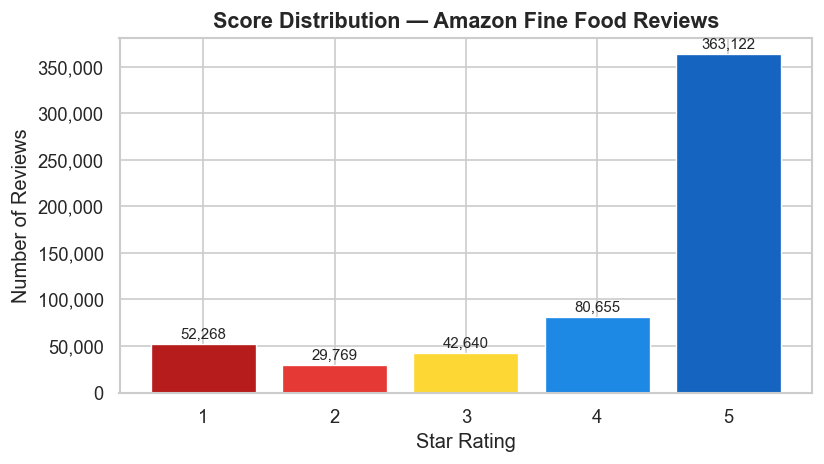

In [4]:
print('3.1  Score Distribution (all 5 stars)')
score_pct = (score_counts_raw / score_counts_raw.sum() * 100).round(2).astype(str) + '%'
print(pd.DataFrame({'Count': score_counts_raw, 'Percentage': score_pct}))
print()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    score_counts_raw.index.astype(str), score_counts_raw.values,
    color=['#B71C1C','#E53935','#FDD835','#1E88E5','#1565C0'],
    edgecolor='white', linewidth=0.8
)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3000,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Score Distribution — Amazon Fine Food Reviews', fontsize=13, fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Number of Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.show()

3.2  Text Length Distribution
count    568454.0
mean        436.2
std         445.3
min          12.0
25%         179.0
50%         302.0
75%         527.0
max       21409.0
Name: Text, dtype: float64



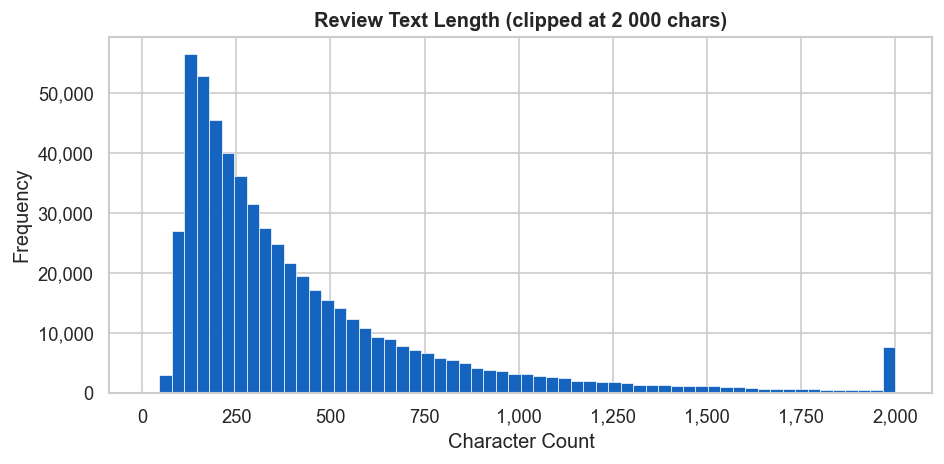

In [5]:
print('3.2  Text Length Distribution')
text_len = df_raw['Text'].fillna('').apply(len)
print(text_len.describe().round(1))
print()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(text_len.clip(upper=2000), bins=60, color='#1565C0', edgecolor='white', linewidth=0.4)
ax.set_title('Review Text Length (clipped at 2 000 chars)', fontsize=12, fontweight='bold')
ax.set_xlabel('Character Count')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.show()

<a id='section-4'></a>
## 4. Data Preprocessing

Pipeline preprocessing:

| Step | Aksi |
|------|------|
| 4.1 | Combine `Summary` + `Text` → `Review_Text` |
| 4.2 | Drop null pada `Review_Text` dan `Score` |
| 4.3 | Hapus duplikat (UserId + ProfileName + Text) |
| 4.4 | Filter Score == 3 (neutral) |
| 4.5 | Buat label Sentiment (Positive / Negative) |
| 4.6 | LabelEncoder (Negative=0, Positive=1) |
| 4.7 | Definisi `clean_text` (lowercase, hapus non-alpha, hapus stopwords kecuali negasi) |
| 4.8 | Apply `clean_text` → `Cleaned_Text` |
| 4.9 | Filter teks terlalu pendek setelah cleaning (< 3 token) |

In [6]:
# 4.1 Combine Summary + Text → Review_Text
df = df_raw.copy()
df['Review_Text'] = (df['Summary'].fillna('') + ' ' + df['Text'].fillna('')).str.strip()
print(f'4.1  Rows after combine          : {len(df):,}')

# 4.2 Drop null
df.dropna(subset=['Review_Text', 'Score'], inplace=True)
df = df[df['Review_Text'].str.strip() != ''].copy()
print(f'4.2  Rows after null-drop        : {len(df):,}')

4.1  Rows after combine          : 568,454
4.2  Rows after null-drop        : 568,454


In [7]:
# 4.3 Remove duplicates (same user, same profile, same review text)
before = len(df)
df.drop_duplicates(subset=['UserId', 'ProfileName', 'Text'], keep='first', inplace=True)
removed = before - len(df)
print(f'4.3  Duplicates removed          : {removed:,}')
print(f'     Rows after dedup            : {len(df):,}')

4.3  Duplicates removed          : 174,807
     Rows after dedup            : 393,647


In [8]:
# 4.4 Filter Score == 3 (neutral — ambiguous, not useful for binary classification)
before = len(df)
df = df[df['Score'] != 3].copy()
print(f'4.4  Neutral (Score=3) removed   : {before - len(df):,}')
print(f'     Rows after neutral filter   : {len(df):,}')
print()

# 4.5 Create Sentiment label
df['Sentiment'] = df['Score'].apply(lambda s: 'Positive' if s >= 4 else 'Negative')
print('4.5  Sentiment distribution:')
print(df['Sentiment'].value_counts())
print()
print('     Percentage:')
print((df['Sentiment'].value_counts(normalize=True) * 100).round(2))

4.4  Neutral (Score=3) removed   : 29,757
     Rows after neutral filter   : 363,890

4.5  Sentiment distribution:
Sentiment
Positive    306809
Negative     57081
Name: count, dtype: int64

     Percentage:
Sentiment
Positive    84.31
Negative    15.69
Name: proportion, dtype: float64


In [9]:
# 4.6 LabelEncoder — Negative=0, Positive=1
le = LabelEncoder()
le.fit(['Negative', 'Positive'])
df['Label'] = le.transform(df['Sentiment'])

print('4.6  LabelEncoder classes :', le.classes_)
print('     Encoding             : Negative=0, Positive=1')

joblib.dump(le, 'label_encoder.pkl')
print('     ✅ label_encoder.pkl saved.')

4.6  LabelEncoder classes : ['Negative' 'Positive']
     Encoding             : Negative=0, Positive=1
     ✅ label_encoder.pkl saved.


In [10]:
# 4.7 clean_text — preserve negations
_NEGATIONS = {
    'not', 'no', 'nor', 'never', 'neither', 'nothing', 'nowhere',
    'nobody', 'none', 'cannot', 'cant', 'dont', 'doesnt', 'didnt',
    'isnt', 'arent', 'wasnt', 'werent', 'hasnt', 'havent', 'hadnt',
    'wont', 'wouldnt', 'shouldnt', 'couldnt', 'mightnt', 'mustnt',
    'neednt', 'shan', 'shant',
}
STOP_WORDS = set(stopwords.words('english')) - _NEGATIONS

def clean_text(text: str) -> str:
    """Lowercase → remove non-alpha → normalize whitespace → remove stopwords.
    Negation words are preserved to distinguish 'not good' from 'good'."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)      # keep only a-z and spaces
    text = re.sub(r'\s+', ' ', text).strip()   # normalize whitespace
    return ' '.join(w for w in text.split() if w not in STOP_WORDS)

# Sanity check
tests = [
    "I can't believe this product is NOT good! It's terrible.",
    "Absolutely amazing! Best coffee I've ever had.",
    "Never buying this again. Worst product ever.",
]
print('4.7  clean_text sanity check:')
for t in tests:
    print(f'  IN : {t}')
    print(f'  OUT: {clean_text(t)}')
    print()

4.7  clean_text sanity check:
  IN : I can't believe this product is NOT good! It's terrible.
  OUT: cant believe product not good terrible

  IN : Absolutely amazing! Best coffee I've ever had.
  OUT: absolutely amazing best coffee ive ever

  IN : Never buying this again. Worst product ever.
  OUT: never buying worst product ever



In [11]:
# 4.8 Apply clean_text
print('4.8  Cleaning text … (may take ~1-2 min on 500k+ rows)')
df['Cleaned_Text'] = df['Review_Text'].apply(clean_text)
print(f'     Done. Rows: {len(df):,}')

4.8  Cleaning text … (may take ~1-2 min on 500k+ rows)
     Done. Rows: 363,890


In [12]:
# 4.9 Filter texts too short after cleaning (< 3 tokens)
# Very short texts (e.g. "good", "ok bad") carry almost no signal
df['token_count'] = df['Cleaned_Text'].str.split().str.len()

print('4.9  Token count distribution after cleaning:')
print(df['token_count'].describe().round(1))
print()

before = len(df)
df = df[df['token_count'] >= 3].copy()
print(f'     Rows removed (< 3 tokens)  : {before - len(df):,}')
print(f'     Final row count            : {len(df):,}')

df.drop(columns=['token_count'], inplace=True)
print()
print('Sample cleaned reviews:')
display(df[['Review_Text', 'Cleaned_Text', 'Sentiment', 'Label']].head(4))

4.9  Token count distribution after cleaning:
count    363890.0
mean         43.5
std          41.0
min           0.0
25%          20.0
50%          31.0
75%          52.0
max        1544.0
Name: token_count, dtype: float64

     Rows removed (< 3 tokens)  : 2
     Final row count            : 363,888

Sample cleaned reviews:


,Review_Text,Cleaned_Text,Sentiment,Label
0,Good Quality Dog Food I have bought several of the Vitality canned dog food products and have found them all to be o...,good quality dog food bought several vitality canned dog food products found good quality product looks like stew pr...,Positive,1
1,Not as Advertised Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. ...,not advertised product arrived labeled jumbo salted peanutsthe peanuts actually small sized unsalted not sure error ...,Negative,0
2,"""Delight"" says it all This is a confection that has been around a few centuries. It is a light, pillowy citrus gela...",delight says confection around centuries light pillowy citrus gelatin nuts case filberts cut tiny squares liberally ...,Positive,1
3,Cough Medicine If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in ...,cough medicine looking secret ingredient robitussin believe found got addition root beer extract ordered good made c...,Negative,0


<a id='section-5'></a>
## 5. Imbalanced Data Analysis & Handling

Class Distribution after preprocessing
  Positive  : 306,807  (84.31%)
  Negative  :  57,081  (15.69%)

  Imbalance ratio (Positive / Negative) : 5.4x


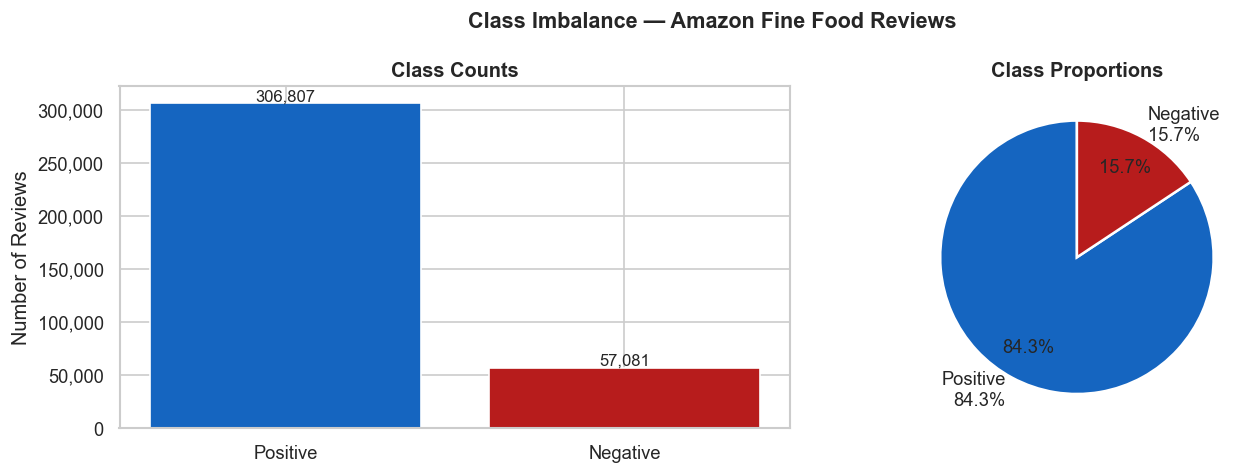

In [13]:
class_counts = df['Sentiment'].value_counts()
class_pct    = (class_counts / class_counts.sum() * 100).round(2)

print('Class Distribution after preprocessing')
for cls in class_counts.index:
    print(f'  {cls:10s}: {class_counts[cls]:>7,}  ({class_pct[cls]:.2f}%)')
print()
ratio = class_counts.max() / class_counts.min()
print(f'  Imbalance ratio (Positive / Negative) : {ratio:.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(class_counts.index, class_counts.values,
            color=[COLOR_POSITIVE, COLOR_NEGATIVE], edgecolor='white')
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt + 2000, f'{cnt:,}', ha='center', fontsize=10)
axes[0].set_title('Class Counts', fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

axes[1].pie(class_counts.values,
            labels=[f'{c}\n{class_pct[c]:.1f}%' for c in class_counts.index],
            colors=[COLOR_POSITIVE, COLOR_NEGATIVE],
            startangle=90, autopct='%1.1f%%', pctdistance=0.75,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Class Proportions', fontweight='bold')

fig.suptitle('Class Imbalance — Amazon Fine Food Reviews', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Mengapa Class Imbalance Menjadi Masalah?

- Dataset memiliki **~84% Positive** vs **~16% Negative** — skew yang sangat besar.
- Classifier naif yang memprediksi **semua** review sebagai Positive akan mencapai ~84% accuracy, namun **tidak mendeteksi satu pun** review negatif.
- Model cenderung memihak kelas mayoritas → **Recall untuk Negative sangat rendah**.
- Accuracy menjadi metrik yang menyesatkan; harus menggunakan **Precision, Recall, dan F1-score** (macro/weighted).

### Strategi Penanganan — Keputusan

**Tidak dilakukan resampling** (tidak oversampling / undersampling).

**Alasan:** resampling pada ~500k baris akan:
- **Oversample** → menduplikasi ratusan ribu baris Negative (biaya memori tinggi)
- **Undersample** → membuang ratusan ribu baris Positive (kehilangan informasi)

**Sebagai gantinya, imbalance ditangani di level algoritma:**

| Model | Mekanisme |
|-------|-----------|
| **Decision Tree** | `class_weight='balanced'` — sklearn menyesuaikan bobot sampel berbanding terbalik dengan frekuensi kelas |
| **Naive Bayes** | `ComplementNB` — dirancang khusus untuk klasifikasi teks dengan data tidak seimbang |

Hypothetical Undersampling (analysis only, NOT applied):
  Original  → Positive: 306,807  |  Negative: 57,081
  Balanced  → Positive: 57,081  |  Negative: 57,081
  Rows kept : 114,162  (discarded 249,726 Positive rows)


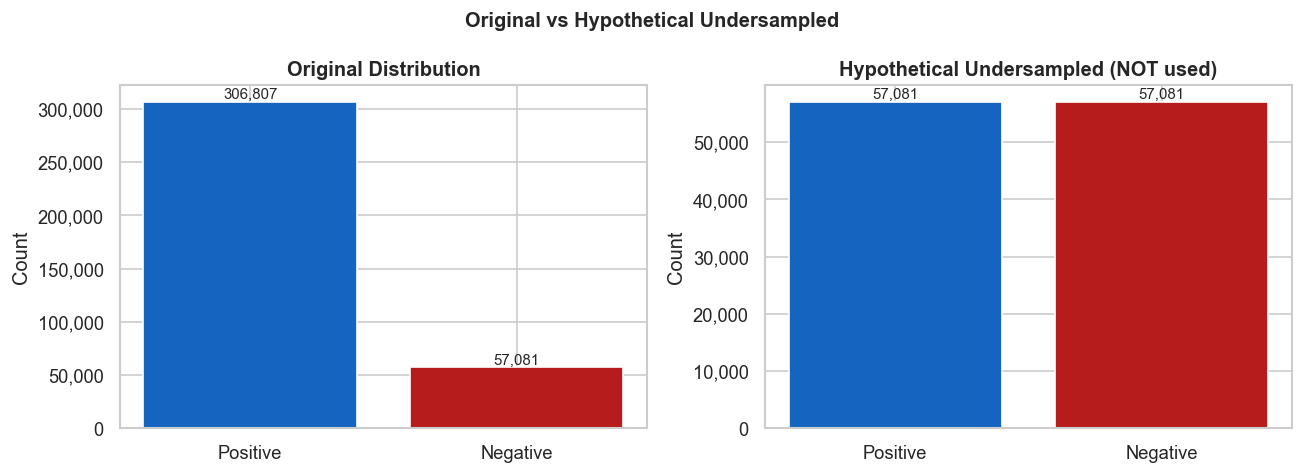

⚠️  Shown for analysis only — actual pipeline uses ORIGINAL imbalanced data.


In [14]:
# Hypothetical undersampling — analysis only, NOT applied
n_neg = class_counts.get('Negative', 0)
n_pos = class_counts.get('Positive', 0)

print('Hypothetical Undersampling (analysis only, NOT applied):')
print(f'  Original  → Positive: {n_pos:,}  |  Negative: {n_neg:,}')
print(f'  Balanced  → Positive: {n_neg:,}  |  Negative: {n_neg:,}')
print(f'  Rows kept : {n_neg*2:,}  (discarded {n_pos-n_neg:,} Positive rows)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (title, vals) in zip(axes, [
    ('Original Distribution', [n_pos, n_neg]),
    ('Hypothetical Undersampled (NOT used)', [n_neg, n_neg])
]):
    ax.bar(['Positive','Negative'], vals,
           color=[COLOR_POSITIVE, COLOR_NEGATIVE], edgecolor='white')
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals)*0.01, f'{v:,}', ha='center', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

fig.suptitle('Original vs Hypothetical Undersampled', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('⚠️  Shown for analysis only — actual pipeline uses ORIGINAL imbalanced data.')

<a id='section-6'></a>
## 6. Export preprocessed_data.csv

In [15]:
KEEP_COLS = ['Id', 'ProductId', 'UserId', 'Score', 'Review_Text', 'Cleaned_Text', 'Sentiment', 'Label']
df_preprocessed = df[KEEP_COLS].reset_index(drop=True)

df_preprocessed.to_csv('preprocessed_data.csv', index=False, encoding='utf-8')

print('✅ Saved preprocessed_data.csv')
print(f'   Rows    : {len(df_preprocessed):,}')
print(f'   Columns : {list(df_preprocessed.columns)}')
print()
display(df_preprocessed.head(3))

✅ Saved preprocessed_data.csv
   Rows    : 363,888
   Columns : ['Id', 'ProductId', 'UserId', 'Score', 'Review_Text', 'Cleaned_Text', 'Sentiment', 'Label']



,Id,ProductId,UserId,Score,Review_Text,Cleaned_Text,Sentiment,Label
0,1,B001E4KFG0,A3SGXH7AUHU8GW,5,Good Quality Dog Food I have bought several of the Vitality canned dog food products and have found them all to be o...,good quality dog food bought several vitality canned dog food products found good quality product looks like stew pr...,Positive,1
1,2,B00813GRG4,A1D87F6ZCVE5NK,1,Not as Advertised Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. ...,not advertised product arrived labeled jumbo salted peanutsthe peanuts actually small sized unsalted not sure error ...,Negative,0
2,3,B000LQOCH0,ABXLMWJIXXAIN,4,"""Delight"" says it all This is a confection that has been around a few centuries. It is a light, pillowy citrus gela...",delight says confection around centuries light pillowy citrus gelatin nuts case filberts cut tiny squares liberally ...,Positive,1


<a id='section-7'></a>
## 7. Data Splitting → train.csv (70%) / val.csv (10%) / test.csv (20%)

| Split | Purpose | Size |
|-------|---------|------|
| **train.csv** | Classical models (DT / NB) + word-embedding training | 70% |
| **val.csv**   | Word-embedding validation only | 10% |
| **test.csv**  | Final evaluation untuk SEMUA model (perbandingan fair) | 20% |

Stratified split mempertahankan distribusi kelas. `random_state=42`.

In [16]:
X = df_preprocessed['Cleaned_Text']
y = df_preprocessed['Label']

print(f'Total samples : {len(X):,}')
print(f'Class balance : {y.value_counts().to_dict()}')
print()

# Step 1: 80% train_val | 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Step 2: dari 80%, ambil 87.5% train | 12.5% val
# 87.5% x 80% = 70% total;  12.5% x 80% = 10% total
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val
)

print('Split sizes:')
print(f'  train : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'  val   : {len(X_val):,}  ({len(X_val)/len(X)*100:.1f}%)')
print(f'  test  : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)')

Total samples : 363,888
Class balance : {1: 306807, 0: 57081}

Split sizes:
  train : 254,721  (70.0%)
  val   : 36,389  (10.0%)
  test  : 72,778  (20.0%)


In [17]:
train_df = df_preprocessed.loc[X_train.index].reset_index(drop=True)
val_df   = df_preprocessed.loc[X_val.index].reset_index(drop=True)
test_df  = df_preprocessed.loc[X_test.index].reset_index(drop=True)

train_df.to_csv('train.csv', index=False, encoding='utf-8')
val_df.to_csv('val.csv',     index=False, encoding='utf-8')
test_df.to_csv('test.csv',   index=False, encoding='utf-8')

print('✅ Saved: train.csv, val.csv, test.csv')

✅ Saved: train.csv, val.csv, test.csv


Data Split Summary
  train   : 254,721 rows  |  Positive: 214,764 (84.3%)  Negative: 39,957 (15.7%)
  val     :  36,389 rows  |  Positive: 30,681 (84.3%)  Negative:  5,708 (15.7%)
  test    :  72,778 rows  |  Positive: 61,362 (84.3%)  Negative: 11,416 (15.7%)
----------------------------------------------------------------------
  TOTAL   : 363,888 rows  |  Positive: 306,807 (84.3%)  Negative: 57,081 (15.7%)


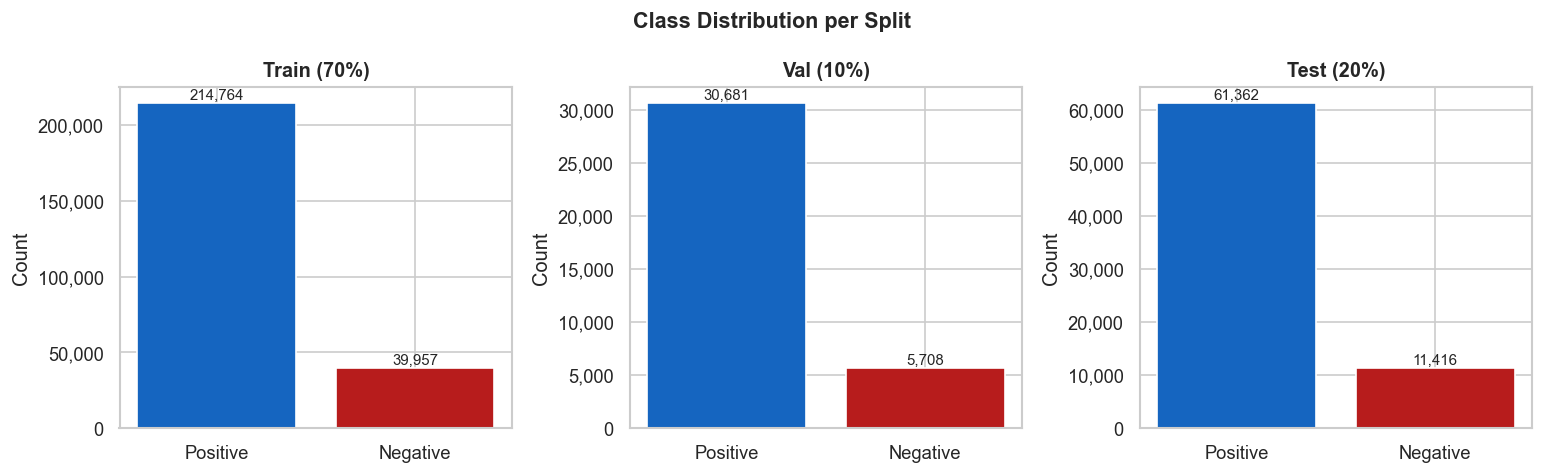

In [18]:
def split_summary(name, df_split):
    total = len(df_split)
    pos   = (df_split['Label'] == 1).sum()
    neg   = (df_split['Label'] == 0).sum()
    print(f'  {name:<8}: {total:>7,} rows  |  '
          f'Positive: {pos:>6,} ({pos/total*100:.1f}%)  '
          f'Negative: {neg:>6,} ({neg/total*100:.1f}%)')

print('=' * 70)
print('Data Split Summary')
print('=' * 70)
split_summary('train', train_df)
split_summary('val',   val_df)
split_summary('test',  test_df)
print('-' * 70)
split_summary('TOTAL', df_preprocessed)
print('=' * 70)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
for ax, (name, split) in zip(axes, [('Train (70%)', train_df),
                                      ('Val (10%)',   val_df),
                                      ('Test (20%)',  test_df)]):
    counts = split['Sentiment'].value_counts()
    ax.bar(counts.index, counts.values,
           color=[COLOR_POSITIVE if c=='Positive' else COLOR_NEGATIVE for c in counts.index],
           edgecolor='white')
    for i, (cls, cnt) in enumerate(counts.items()):
        ax.text(i, cnt + counts.max()*0.01, f'{cnt:,}', ha='center', fontsize=9)
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

fig.suptitle('Class Distribution per Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✅ Preprocessing Complete

| File | Deskripsi |
|------|-----------|
| `preprocessed_data.csv` | Dataset lengkap setelah cleaning & labelling |
| `label_encoder.pkl` | Fitted LabelEncoder (Negative=0, Positive=1) |
| `train.csv` | 70% — classical models + embedding training |
| `val.csv` | 10% — embedding validation |
| `test.csv` | 20% — evaluasi final semua model |

**Next step →** `02_classical_models.ipynb`

# 02 — Classical Models: Decision Tree & Naive Bayes
## Amazon Fine Food Reviews — NLP Sentiment Classification

This notebook trains and evaluates **6 classical NLP experiments**:

| # | Model | Feature Extraction |
|---|-------|--------------------|
| 1 | Decision Tree | BOW (Bag of Words) |
| 2 | Decision Tree | N-Gram (unigrams + bigrams) |
| 3 | Decision Tree | TF-IDF |
| 4 | Naive Bayes (Complement) | BOW |
| 5 | Naive Bayes (Complement) | N-Gram |
| 6 | Naive Bayes (Complement) | TF-IDF |

**Data split:** Train (70%) + Val (10%) = 80% for training | Test (20%) for evaluation

---
## Section 1: Setup & Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import time
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [20]:
# Color constants
COLOR_POSITIVE = '#1565C0'
COLOR_NEGATIVE = '#B71C1C'
COLOR_BOW      = '#1B5E20'
COLOR_NGRAM    = '#388E3C'
COLOR_TFIDF    = '#81C784'
COLOR_NB_BOW   = '#4A148C'
COLOR_NB_NGRAM = '#7B1FA2'
COLOR_NB_TFIDF = '#CE93D8'
COLOR_DT  = [COLOR_BOW, COLOR_NGRAM, COLOR_TFIDF]
COLOR_NB  = [COLOR_NB_BOW, COLOR_NB_NGRAM, COLOR_NB_TFIDF]
COLOR_ALL = COLOR_DT + COLOR_NB

print('Color constants defined.')

Color constants defined.


---
## Section 2: Load Data

In [21]:
# Load splits
df_train_raw = pd.read_csv('train.csv')
df_val       = pd.read_csv('val.csv')
df_test      = pd.read_csv('test.csv')

# Load label encoder
label_encoder = joblib.load('label_encoder.pkl')

# Combine train + val for 80% training set
df_train = pd.concat([df_train_raw, df_val], ignore_index=True)

# Fill NaN in Cleaned_Text
df_train['Cleaned_Text'] = df_train['Cleaned_Text'].fillna('')
df_test['Cleaned_Text']  = df_test['Cleaned_Text'].fillna('')

# Features and labels
X_train = df_train['Cleaned_Text']
y_train = df_train['Label']
X_test  = df_test['Cleaned_Text']
y_test  = df_test['Label']

print(f'Train set size : {len(df_train):,} samples')
print(f'Test  set size : {len(df_test):,} samples')
print()
print('Train class distribution:')
print(y_train.value_counts().to_string())
print()
print('Test class distribution:')
print(y_test.value_counts().to_string())

Train set size : 291,110 samples
Test  set size : 72,778 samples

Train class distribution:
Label
1    245445
0     45665

Test class distribution:
Label
1    61362
0    11416


---
## Section 3: Feature Extraction (BOW, N-Gram, TF-IDF)

In [22]:
# BOW — unigrams
vec_bow = CountVectorizer(ngram_range=(1, 1), max_features=10000, min_df=2)

# N-Gram — unigrams + bigrams
vec_ngram = CountVectorizer(ngram_range=(1, 2), max_features=10000, min_df=2)

# TF-IDF — unigrams
vec_tfidf = TfidfVectorizer(ngram_range=(1, 1), max_features=10000, min_df=2)

# Fit on train, transform both splits
X_train_bow   = vec_bow.fit_transform(X_train)
X_test_bow    = vec_bow.transform(X_test)

X_train_ngram = vec_ngram.fit_transform(X_train)
X_test_ngram  = vec_ngram.transform(X_test)

X_train_tfidf = vec_tfidf.fit_transform(X_train)
X_test_tfidf  = vec_tfidf.transform(X_test)

# Summary table
summary = pd.DataFrame({
    'Vectorizer'   : ['BOW', 'N-Gram', 'TF-IDF'],
    'Train Shape'  : [X_train_bow.shape, X_train_ngram.shape, X_train_tfidf.shape],
    'Test Shape'   : [X_test_bow.shape,  X_test_ngram.shape,  X_test_tfidf.shape],
    'Vocab Size'   : [
        len(vec_bow.vocabulary_),
        len(vec_ngram.vocabulary_),
        len(vec_tfidf.vocabulary_)
    ]
})
print(summary.to_string(index=False))

Vectorizer     Train Shape     Test Shape  Vocab Size
       BOW (291110, 10000) (72778, 10000)       10000
    N-Gram (291110, 10000) (72778, 10000)       10000
    TF-IDF (291110, 10000) (72778, 10000)       10000


---
## Section 4: Model Training — Decision Tree (3 Experiments)

In [23]:
DT_PARAMS = {
    'criterion'        : 'gini',
    'max_depth'        : 30,
    'min_samples_split': 5,
    'min_samples_leaf' : 2,
    'class_weight'     : 'balanced',
    'random_state'     : 42
}

results = {}

def train_and_evaluate(name, model, X_tr, X_te, y_tr, y_te, vectorizer):
    """Train model, evaluate on test set, store results."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='macro', zero_division=0)
    cm   = confusion_matrix(y_te, y_pred)

    results[name] = {
        'accuracy'  : acc,
        'precision' : prec,
        'recall'    : rec,
        'f1'        : f1,
        'train_time': train_time,
        'cm'        : cm,
        'model'     : model,
        'vectorizer': vectorizer
    }

    print(f'[{name}]')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  F1-macro  : {f1:.4f}')
    print(f'  Train time: {train_time:.2f}s')
    print()
    return results[name]

In [24]:
# DT + BOW
model_dt_bow = DecisionTreeClassifier(**DT_PARAMS)
train_and_evaluate('DT + BOW', model_dt_bow, X_train_bow, X_test_bow, y_train, y_test, vec_bow)

# DT + N-Gram
model_dt_ngram = DecisionTreeClassifier(**DT_PARAMS)
train_and_evaluate('DT + N-Gram', model_dt_ngram, X_train_ngram, X_test_ngram, y_train, y_test, vec_ngram)

# DT + TF-IDF
model_dt_tfidf = DecisionTreeClassifier(**DT_PARAMS)
train_and_evaluate('DT + TF-IDF', model_dt_tfidf, X_train_tfidf, X_test_tfidf, y_train, y_test, vec_tfidf)

print('Decision Tree experiments complete.')

[DT + BOW]
  Accuracy  : 0.8297
  F1-macro  : 0.7419
  Train time: 115.81s

[DT + N-Gram]
  Accuracy  : 0.8386
  F1-macro  : 0.7522
  Train time: 129.59s

[DT + TF-IDF]
  Accuracy  : 0.8195
  F1-macro  : 0.7322
  Train time: 126.04s

Decision Tree experiments complete.


---
## Section 5: Model Training — Naive Bayes (3 Experiments)

In [25]:
NB_PARAMS = {'alpha': 1.0, 'norm': False}

# NB + BOW
model_nb_bow = ComplementNB(**NB_PARAMS)
train_and_evaluate('NB + BOW', model_nb_bow, X_train_bow, X_test_bow, y_train, y_test, vec_bow)

# NB + N-Gram
model_nb_ngram = ComplementNB(**NB_PARAMS)
train_and_evaluate('NB + N-Gram', model_nb_ngram, X_train_ngram, X_test_ngram, y_train, y_test, vec_ngram)

# NB + TF-IDF
model_nb_tfidf = ComplementNB(**NB_PARAMS)
train_and_evaluate('NB + TF-IDF', model_nb_tfidf, X_train_tfidf, X_test_tfidf, y_train, y_test, vec_tfidf)

print('Naive Bayes experiments complete.')

[NB + BOW]
  Accuracy  : 0.9017
  F1-macro  : 0.8385
  Train time: 0.06s

[NB + N-Gram]
  Accuracy  : 0.9087
  F1-macro  : 0.8500
  Train time: 0.05s

[NB + TF-IDF]
  Accuracy  : 0.8911
  F1-macro  : 0.8247
  Train time: 0.05s

Naive Bayes experiments complete.


---
## Section 6: Model Evaluation — Confusion Matrices

2-row × 3-column grid: Row 1 = Decision Tree, Row 2 = Naive Bayes

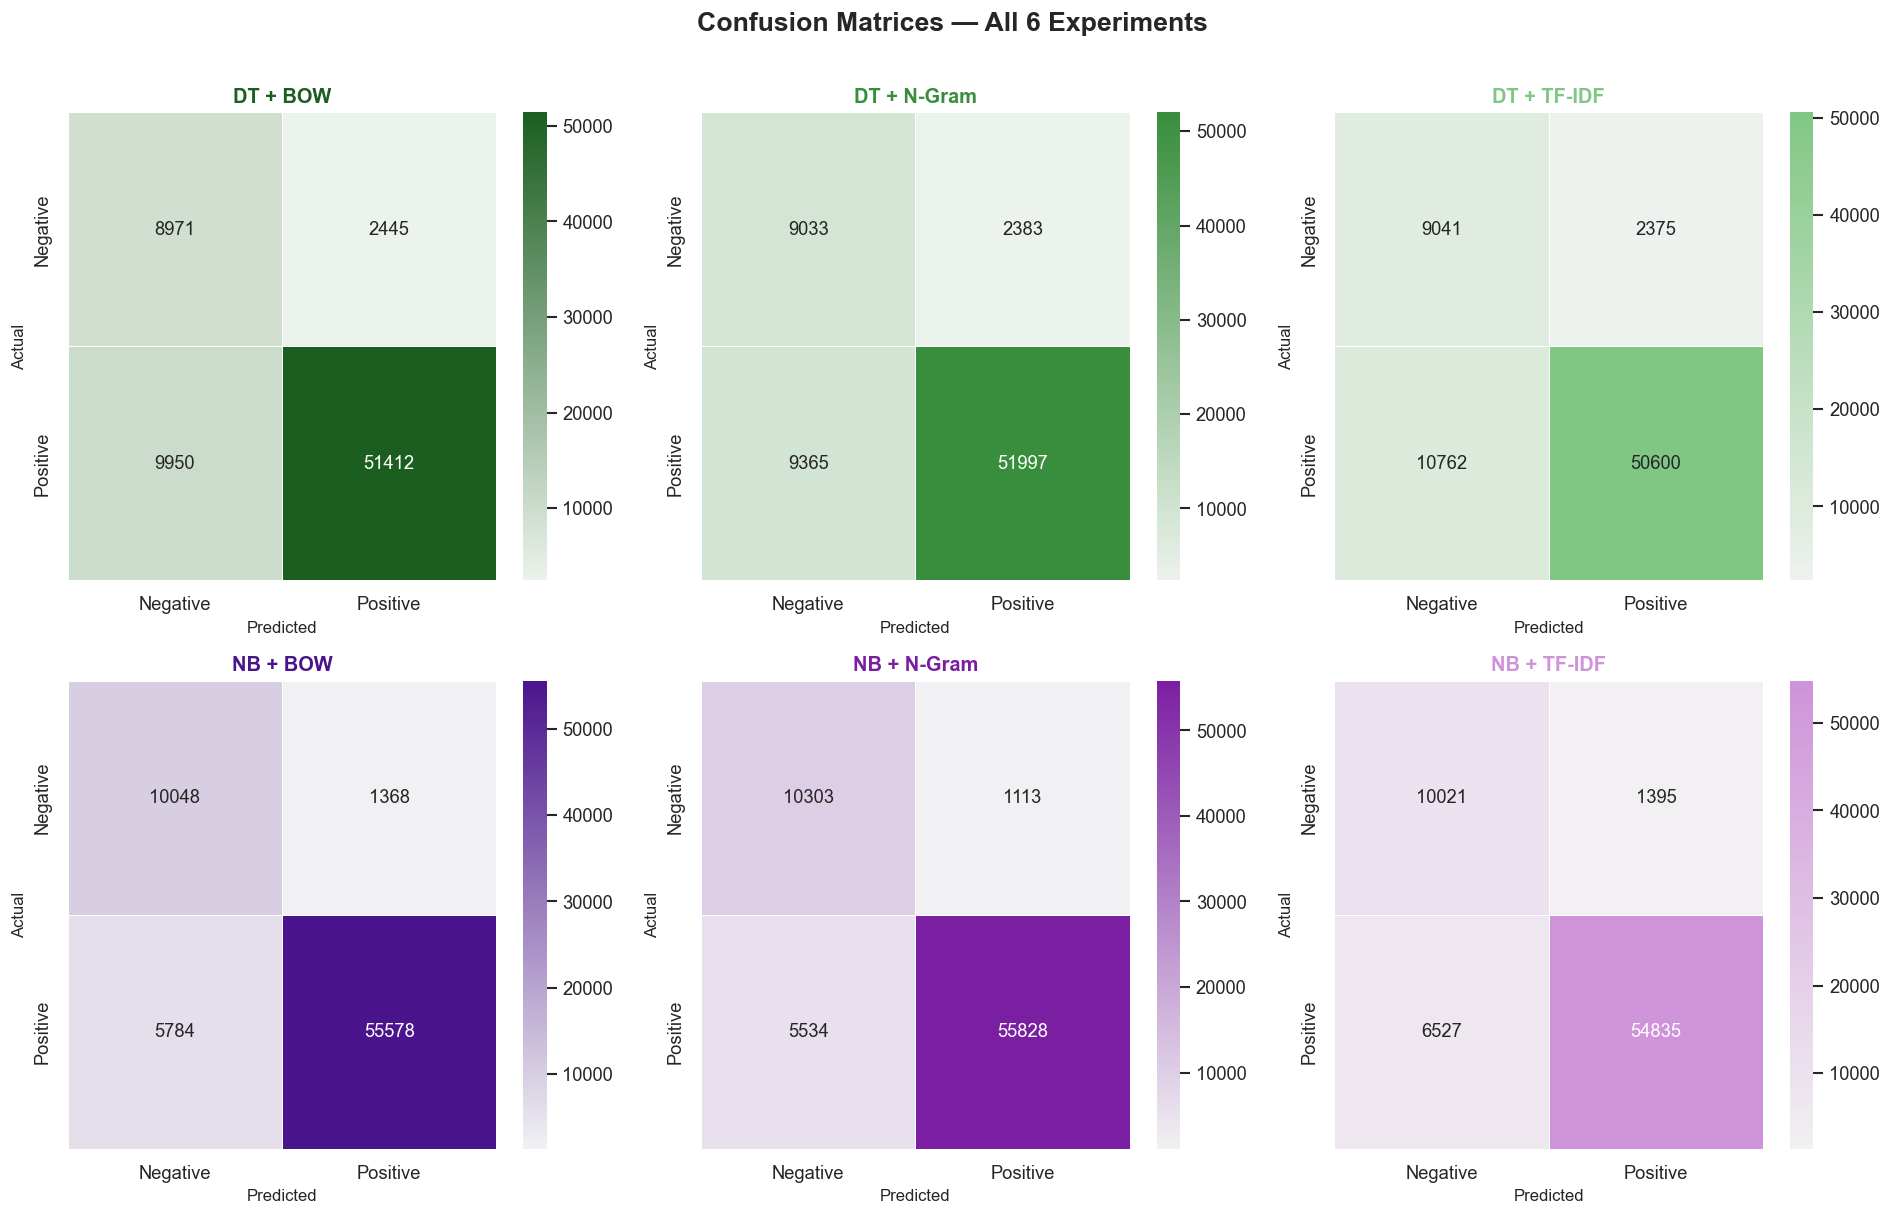

In [26]:
exp_names = [
    'DT + BOW', 'DT + N-Gram', 'DT + TF-IDF',
    'NB + BOW', 'NB + N-Gram', 'NB + TF-IDF'
]
class_labels = ['Negative', 'Positive']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices — All 6 Experiments', fontsize=16, fontweight='bold', y=1.01)

for idx, name in enumerate(exp_names):
    row = idx // 3
    col = idx % 3
    ax  = axes[row][col]
    cm  = results[name]['cm']
    color = COLOR_ALL[idx]

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=sns.light_palette(color, as_cmap=True),
        xticklabels=class_labels,
        yticklabels=class_labels,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(name, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.show()

---
## Section 7: Model Comparison

### 7.1 Summary Table

In [27]:
rows = []
for name in exp_names:
    r = results[name]
    rows.append({
        'Experiment'    : name,
        'Accuracy'      : round(r['accuracy'],  4),
        'Precision'     : round(r['precision'], 4),
        'Recall'        : round(r['recall'],    4),
        'F1-macro'      : round(r['f1'],        4),
        'Train Time (s)': round(r['train_time'],2)
    })

df_summary = pd.DataFrame(rows).sort_values('F1-macro', ascending=False).reset_index(drop=True)
df_summary.index += 1
print(df_summary.to_string())

    Experiment  Accuracy  Precision  Recall  F1-macro  Train Time (s)
1  NB + N-Gram    0.9087     0.8155  0.9062    0.8500            0.05
2     NB + BOW    0.9017     0.8053  0.8930    0.8385            0.06
3  NB + TF-IDF    0.8911     0.7904  0.8857    0.8247            0.05
4  DT + N-Gram    0.8386     0.7236  0.8193    0.7522          129.59
5     DT + BOW    0.8297     0.7144  0.8118    0.7419          115.81
6  DT + TF-IDF    0.8195     0.7059  0.8083    0.7322          126.04


### 7.2 Grouped Bar Chart — All 4 Metrics

KeyError: 'DT + BOW'

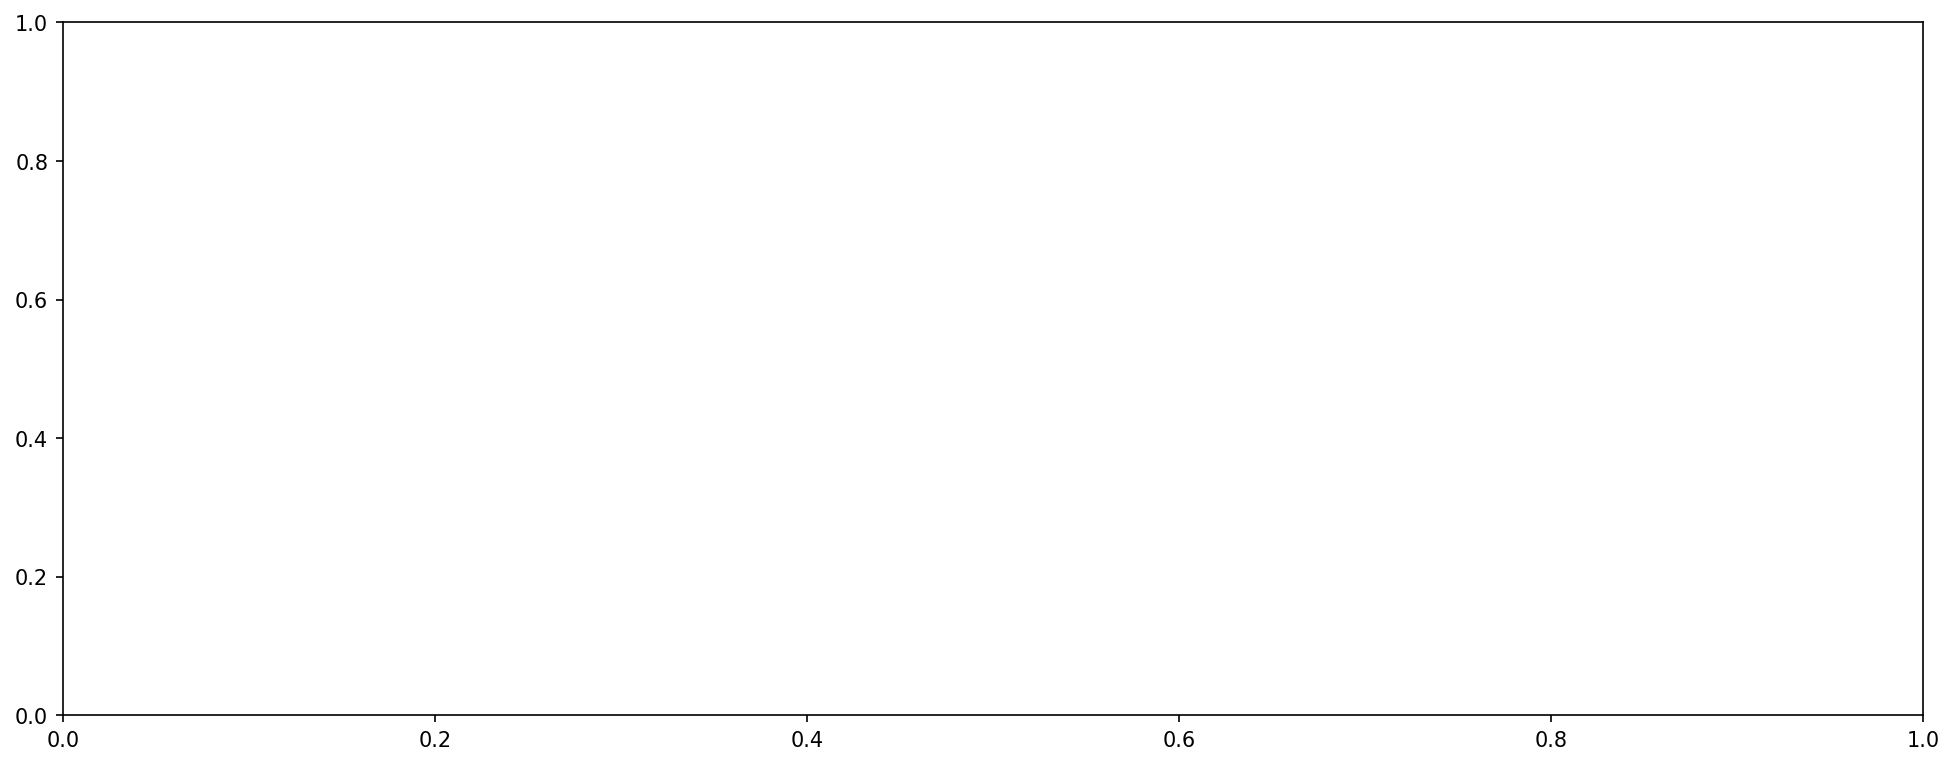

In [45]:
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1-macro']
metric_keys  = ['accuracy', 'precision', 'recall', 'f1']
n_experiments = len(exp_names)
n_metrics     = len(metrics)

bar_width = 0.15
x = np.arange(n_experiments)
offsets = np.linspace(-(n_metrics - 1) / 2, (n_metrics - 1) / 2, n_metrics) * bar_width

fig, ax = plt.subplots(figsize=(16, 6))

metric_colors = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']

for i, (metric, key, color) in enumerate(zip(metrics, metric_keys, metric_colors)):
    values = [results[name][key] for name in exp_names]
    bars = ax.bar(x + offsets[i], values, width=bar_width, label=metric, color=color, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=6.5, rotation=90
        )

ax.set_xticks(x)
ax.set_xticklabels(exp_names, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('All Metrics — 6 Experiments', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 7.3 Radar Chart — All 6 Experiments

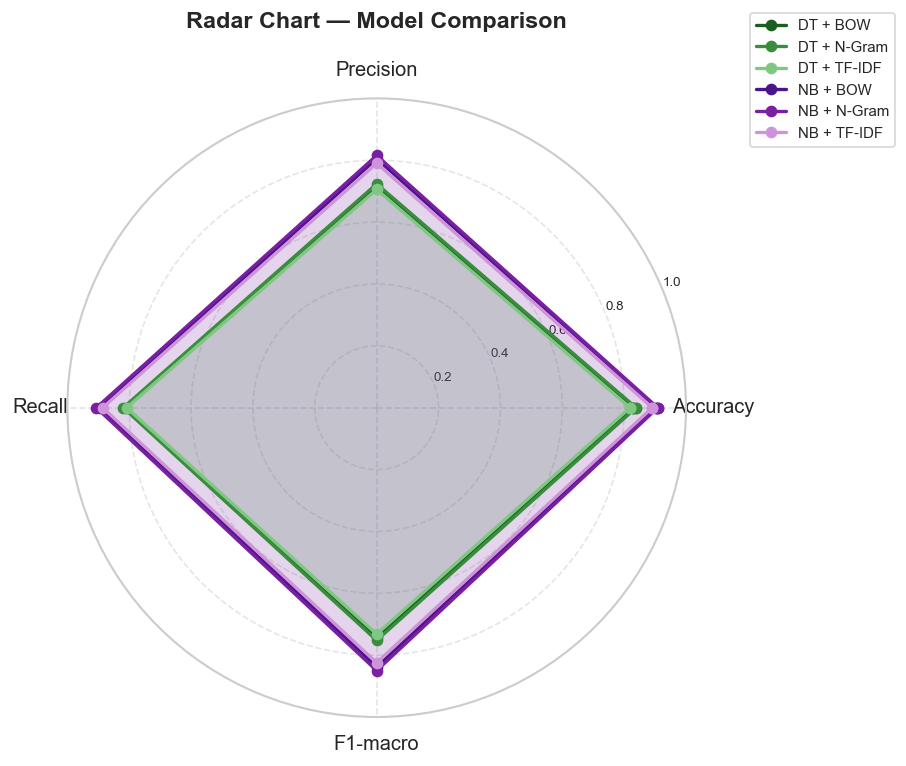

In [29]:
radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-macro']
radar_keys    = ['accuracy', 'precision', 'recall', 'f1']
num_vars      = len(radar_metrics)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, color in zip(exp_names, COLOR_ALL):
    values = [results[name][k] for k in radar_keys]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=name)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('Radar Chart — Model Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 7.4 Accuracy Ranking — Horizontal Bar Chart

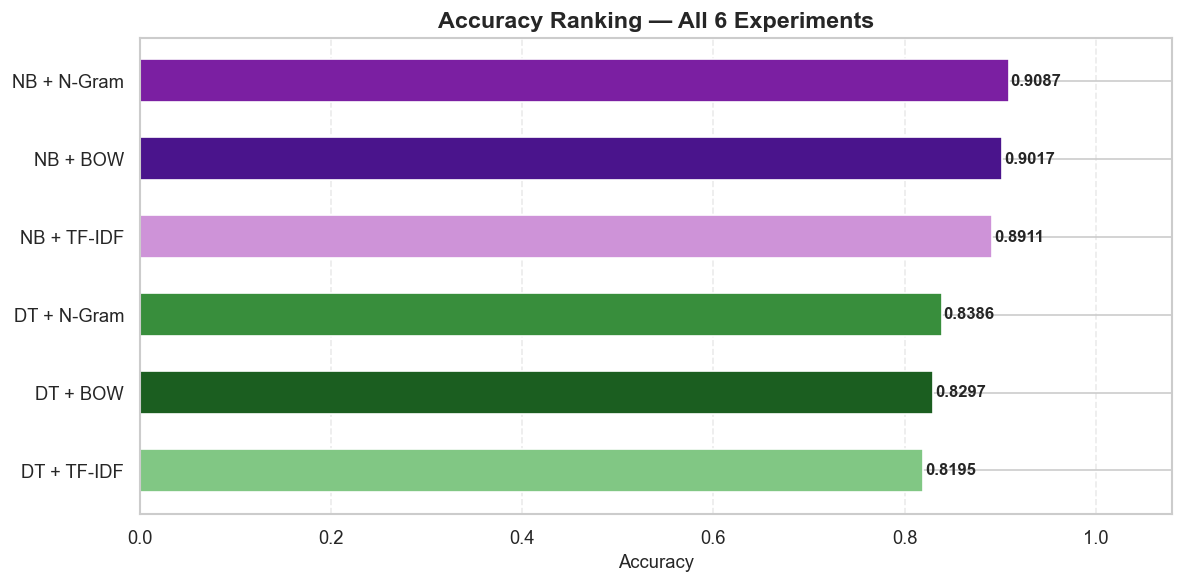

In [30]:
acc_data = sorted(
    [(name, results[name]['accuracy'], COLOR_ALL[i]) for i, name in enumerate(exp_names)],
    key=lambda x: x[1]
)

names_sorted  = [d[0] for d in acc_data]
accs_sorted   = [d[1] for d in acc_data]
colors_sorted = [d[2] for d in acc_data]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names_sorted, accs_sorted, color=colors_sorted, edgecolor='white', height=0.55)

for bar, val in zip(bars, accs_sorted):
    ax.text(
        val + 0.002, bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}', va='center', ha='left', fontsize=10, fontweight='bold'
    )

ax.set_xlim(0, 1.08)
ax.set_xlabel('Accuracy', fontsize=11)
ax.set_title('Accuracy Ranking — All 6 Experiments', fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 7.5 Best Model

In [31]:
best_name = max(results, key=lambda k: results[k]['f1'])
best      = results[best_name]

print(f'Best model    : {best_name}')
print(f'  Accuracy    : {best["accuracy"]:.4f}')
print(f'  Precision   : {best["precision"]:.4f}')
print(f'  Recall      : {best["recall"]:.4f}')
print(f'  F1-macro    : {best["f1"]:.4f}')
print(f'  Train time  : {best["train_time"]:.2f}s')

Best model    : NB + N-Gram
  Accuracy    : 0.9087
  Precision   : 0.8155
  Recall      : 0.9062
  F1-macro    : 0.8500
  Train time  : 0.05s


---
## Section 8: Save Artifacts

In [32]:
# Save models
joblib.dump(model_dt_bow,   'model_dt_bow.pkl')
joblib.dump(model_dt_ngram, 'model_dt_ngram.pkl')
joblib.dump(model_dt_tfidf, 'model_dt_tfidf.pkl')
joblib.dump(model_nb_bow,   'model_nb_bow.pkl')
joblib.dump(model_nb_ngram, 'model_nb_ngram.pkl')
joblib.dump(model_nb_tfidf, 'model_nb_tfidf.pkl')

# Save vectorizers
joblib.dump(vec_bow,   'vectorizer_bow.pkl')
joblib.dump(vec_ngram, 'vectorizer_ngram.pkl')
joblib.dump(vec_tfidf, 'vectorizer_tfidf.pkl')

# Print file sizes
artifact_files = [
    'model_dt_bow.pkl', 'model_dt_ngram.pkl', 'model_dt_tfidf.pkl',
    'model_nb_bow.pkl', 'model_nb_ngram.pkl', 'model_nb_tfidf.pkl',
    'vectorizer_bow.pkl', 'vectorizer_ngram.pkl', 'vectorizer_tfidf.pkl'
]

print('Saved artifacts:')
for fname in artifact_files:
    size_kb = os.path.getsize(fname) / 1024
    print(f'  {fname:<30} {size_kb:>8.1f} KB')

Saved artifacts:
  model_dt_bow.pkl                 1199.3 KB
  model_dt_ngram.pkl               1117.4 KB
  model_dt_tfidf.pkl               1046.3 KB
  model_nb_bow.pkl                  391.5 KB
  model_nb_ngram.pkl                391.5 KB
  model_nb_tfidf.pkl                391.5 KB
  vectorizer_bow.pkl                281.0 KB
  vectorizer_ngram.pkl              298.2 KB
  vectorizer_tfidf.pkl              359.4 KB


In [33]:
# Save classical_metrics.json for the dashboard
metrics_for_dashboard = {}
for exp_name, res in results.items():
    metrics_for_dashboard[exp_name] = {
        'accuracy'        : res['accuracy'],
        'precision'       : res['precision'],
        'recall'          : res['recall'],
        'f1'              : res['f1'],
        'confusion_matrix': res['cm'].tolist()
    }

with open('classical_metrics.json', 'w') as f:
    json.dump(metrics_for_dashboard, f, indent=2)

print('Saved classical_metrics.json')
size_kb = os.path.getsize('classical_metrics.json') / 1024
print(f'  classical_metrics.json          {size_kb:>8.1f} KB')

Saved classical_metrics.json
  classical_metrics.json               1.7 KB


---
## Summary

All 6 classical NLP experiments have been trained and evaluated:

- **3 Decision Tree** models (BOW, N-Gram, TF-IDF)
- **3 Complement Naive Bayes** models (BOW, N-Gram, TF-IDF)

Artifacts saved:
- 6 model `.pkl` files
- 3 vectorizer `.pkl` files
- `classical_metrics.json` for the dashboard

Proceed to `03_deep_learning_models.ipynb` for LSTM / Transformer experiments.

# 03 — Word Embedding Models: GloVe + MLP & Word2Vec + MLP
## Amazon Fine Food Reviews — NLP Sentiment Classification

| # | Embedding | Type | Classifier |
|---|-----------|------|------------|
| 1 | GloVe 6B 50d | Pre-trained, non-contextual, **frozen** | GlobalAveragePooling + Dense |
| 2 | Word2Vec (trained on dataset) | Non-contextual, **fine-tuned** | GlobalAveragePooling + Dense |

**Data split:** `train.csv` (70%) → training | `val.csv` (10%) → validation / early stopping | `test.csv` (20%) → final evaluation

---

## 1. Setup & Imports

In [35]:
import subprocess, sys
try:
    import gensim  
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gensim', '--quiet'])

try:
    import tensorflow
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow', '--quiet'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib, json, os, time, pickle, warnings
warnings.filterwarnings('ignore')

from gensim.models import Word2Vec
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f'TensorFlow : {tf.__version__}')
print('✅ Libraries loaded.')

TensorFlow : 2.21.0
✅ Libraries loaded.


In [36]:
COLOR_POSITIVE  = '#1565C0'
COLOR_NEGATIVE  = '#B71C1C'
COLOR_GLOVE     = '#E65100'
COLOR_WORD2VEC  = '#00695C'
COLOR_EMBEDDING = [COLOR_GLOVE, COLOR_WORD2VEC]
print('Color constants defined.')

Color constants defined.


## 2. Load Data

In [37]:
df_train = pd.read_csv('train.csv')
df_val   = pd.read_csv('val.csv')
df_test  = pd.read_csv('test.csv')
label_encoder = joblib.load('label_encoder.pkl')

for df in [df_train, df_val, df_test]:
    df['Cleaned_Text'] = df['Cleaned_Text'].fillna('')

X_train, y_train = df_train['Cleaned_Text'], df_train['Label']
X_val,   y_val   = df_val['Cleaned_Text'],   df_val['Label']
X_test,  y_test  = df_test['Cleaned_Text'],  df_test['Label']

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')
print()
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    vc = y.value_counts()
    print(f'{name} — Negative: {vc.get(0,0):,}  Positive: {vc.get(1,0):,}')

Train : 254,721  |  Val : 36,389  |  Test : 72,778

Train — Negative: 39,957  Positive: 214,764
Val — Negative: 5,708  Positive: 30,681
Test — Negative: 11,416  Positive: 61,362


## 3. Text Tokenization

In [38]:
MAX_VOCAB = 20000
MAX_LEN   = 200

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

def encode(texts):
    return pad_sequences(
        tokenizer.texts_to_sequences(texts),
        maxlen=MAX_LEN, padding='post', truncating='post'
    )

X_train_seq = encode(X_train)
X_val_seq   = encode(X_val)
X_test_seq  = encode(X_test)

print(f'MAX_VOCAB      : {MAX_VOCAB:,}')
print(f'Full vocab size: {len(tokenizer.word_index):,}')
print(f'X_train_seq    : {X_train_seq.shape}')
print(f'X_val_seq      : {X_val_seq.shape}')
print(f'X_test_seq     : {X_test_seq.shape}')

MAX_VOCAB      : 20,000
Full vocab size: 177,961
X_train_seq    : (254721, 200)
X_val_seq      : (36389, 200)
X_test_seq     : (72778, 200)


## 4. GloVe + MLP

### 4.1 Load GloVe Embeddings

> **Download:** [https://nlp.stanford.edu/data/glove.6B.zip](https://nlp.stanford.edu/data/glove.6B.zip)  
> Extract `glove.6B.50d.txt` ke folder project (direktori yang sama dengan notebook ini).

In [39]:
GLOVE_PATH = 'glove.6B.50d.txt'
EMBED_DIM  = 50

glove_embeddings = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        glove_embeddings[parts[0]] = np.array(parts[1:], dtype='float32')

print(f'GloVe vocab size: {len(glove_embeddings):,}')

GloVe vocab size: 400,000


### 4.2 Build GloVe Embedding Matrix

In [40]:
word_index = tokenizer.word_index
vocab_size = min(MAX_VOCAB, len(word_index)) + 1

embedding_matrix_glove = np.zeros((vocab_size, EMBED_DIM))
for word, idx in word_index.items():
    if idx < vocab_size:
        vec = glove_embeddings.get(word)
        if vec is not None:
            embedding_matrix_glove[idx] = vec

coverage = sum(1 for w in word_index if glove_embeddings.get(w) is not None)
print(f'Embedding matrix : {embedding_matrix_glove.shape}')
print(f'GloVe coverage   : {coverage:,} / {len(word_index):,} ({coverage/len(word_index)*100:.1f}%)')

Embedding matrix : (20001, 50)
GloVe coverage   : 53,119 / 177,961 (29.8%)


### 4.3 Build & Train GloVe MLP

In [41]:
def build_embedding_mlp(vocab_size, embed_dim, embedding_matrix, max_len, trainable=False):
    inp = keras.Input(shape=(max_len,))
    x = layers.Embedding(
        input_dim=vocab_size, output_dim=embed_dim,
        weights=[embedding_matrix], trainable=trainable, mask_zero=True
    )(inp)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy', metrics=['accuracy']
    )
    return model

BATCH_SIZE = 512
EPOCHS     = 20
CALLBACKS  = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

model_glove = build_embedding_mlp(vocab_size, EMBED_DIM, embedding_matrix_glove, MAX_LEN, trainable=False)
model_glove.summary()

t0 = time.time()
history_glove = model_glove.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=CALLBACKS, verbose=1
)
train_time_glove = time.time() - t0
print(f'Training time: {train_time_glove:.1f}s')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 50)   │  1,000,050 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 200)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 50)        │          0 │ embedding[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     13,056 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,046,131 (3.99 MB)

 Trainable params: 46,081 (180.00 KB)

 Non-trainable params: 1,000,050 (3.81 MB)

Epoch 1/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8699 - loss: 0.3149 - val_accuracy: 0.8812 - val_loss: 0.2865 - learning_rate: 0.0010
Epoch 2/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8793 - loss: 0.2890 - val_accuracy: 0.8840 - val_loss: 0.2805 - learning_rate: 0.0010
Epoch 3/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8819 - loss: 0.2841 - val_accuracy: 0.8859 - val_loss: 0.2770 - learning_rate: 0.0010
Epoch 4/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8828 - loss: 0.2810 - val_accuracy: 0.8865 - val_loss: 0.2745 - learning_rate: 0.0010
Epoch 5/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8835 - loss: 0.2788 - val_accuracy: 0.8866 - val_loss: 0.2726 - learning_rate: 0.0010
Epoch 6/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8845 - loss: 0.2774 - val_accuracy: 0.8853 - val_loss: 0.2778 - learning_rate: 0.0010
Epoch 7/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8853 - loss: 0.2759 - 

### 4.4 Evaluate GloVe MLP

In [42]:
y_pred_glove = (model_glove.predict(X_test_seq, batch_size=512).flatten() >= 0.5).astype(int)

embedding_results = {}
embedding_results['GloVe + MLP'] = {
    'accuracy'  : accuracy_score(y_test, y_pred_glove),
    'precision' : precision_score(y_test, y_pred_glove, average='macro', zero_division=0),
    'recall'    : recall_score(y_test, y_pred_glove, average='macro', zero_division=0),
    'f1'        : f1_score(y_test, y_pred_glove, average='macro', zero_division=0),
    'train_time': train_time_glove,
    'cm'        : confusion_matrix(y_test, y_pred_glove)
}

r = embedding_results['GloVe + MLP']
print('GloVe + MLP — Test Set')
print(f'  Accuracy  : {r["accuracy"]:.4f}')
print(f'  Precision : {r["precision"]:.4f}')
print(f'  Recall    : {r["recall"]:.4f}')
print(f'  F1-macro  : {r["f1"]:.4f}')
print()
print(classification_report(y_test, y_pred_glove, target_names=['Negative','Positive']))

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
GloVe + MLP — Test Set
  Accuracy  : 0.8895
  Precision : 0.8149
  Recall    : 0.7238
  F1-macro  : 0.7572

              precision    recall  f1-score   support

    Negative       0.72      0.48      0.58     11416
    Positive       0.91      0.97      0.94     61362

    accuracy                           0.89     72778
   macro avg       0.81      0.72      0.76     72778
weighted avg       0.88      0.89      0.88     72778



### 4.5 GloVe Training History

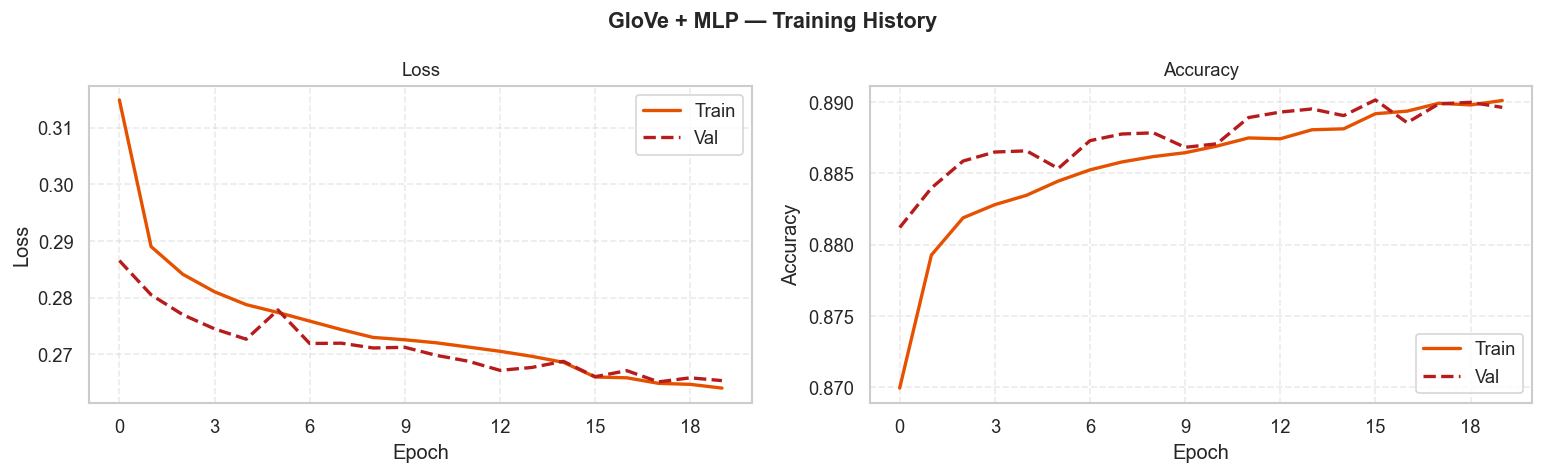

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('GloVe + MLP — Training History', fontsize=13, fontweight='bold')
for ax, (metric, val_metric, ylabel) in zip(axes, [
    ('loss', 'val_loss', 'Loss'),
    ('accuracy', 'val_accuracy', 'Accuracy')
]):
    ax.plot(history_glove.history[metric],     label='Train', color=COLOR_GLOVE,    lw=2)
    ax.plot(history_glove.history[val_metric], label='Val',   color=COLOR_NEGATIVE, lw=2, ls='--')
    ax.set_title(ylabel, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(ls='--', alpha=0.4)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 5. Word2Vec + MLP

### 5.1 Train Word2Vec on Training Corpus

In [44]:
W2V_DIM       = 50
W2V_WINDOW    = 5
W2V_MIN_COUNT = 2
W2V_EPOCHS    = 10

train_sentences = [text.split() for text in X_train]

t0 = time.time()
w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=W2V_DIM,
    window=W2V_WINDOW,
    min_count=W2V_MIN_COUNT,
    workers=4,
    epochs=W2V_EPOCHS,
    seed=42
)
print(f'Word2Vec training time  : {time.time()-t0:.1f}s')
print(f'Word2Vec vocabulary size: {len(w2v_model.wv):,}')

Word2Vec training time  : 32.0s
Word2Vec vocabulary size: 71,769


### 5.2 Build Word2Vec Embedding Matrix

In [45]:
embedding_matrix_w2v = np.zeros((vocab_size, W2V_DIM))
for word, idx in word_index.items():
    if idx < vocab_size and word in w2v_model.wv:
        embedding_matrix_w2v[idx] = w2v_model.wv[word]

coverage_w2v = sum(1 for w in word_index if w in w2v_model.wv)
print(f'Embedding matrix   : {embedding_matrix_w2v.shape}')
print(f'Word2Vec coverage  : {coverage_w2v:,} / {len(word_index):,} ({coverage_w2v/len(word_index)*100:.1f}%)')

Embedding matrix   : (20001, 50)
Word2Vec coverage  : 71,769 / 177,961 (40.3%)


### 5.3 Build & Train Word2Vec MLP

Same architecture as GloVe MLP, but `trainable=True` — embeddings are fine-tuned during training.

In [46]:
model_w2v = build_embedding_mlp(vocab_size, W2V_DIM, embedding_matrix_w2v, MAX_LEN, trainable=True)
model_w2v.summary()

t0 = time.time()
history_w2v = model_w2v.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=CALLBACKS, verbose=1
)
train_time_w2v = time.time() - t0
print(f'Training time: {train_time_w2v:.1f}s')

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 50)   │  1,000,050 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 200)       │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 50)        │          0 │ embedding_1[0][0… │
│ (GlobalAveragePool… │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     13,056 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │        129 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,046,131 (3.99 MB)

 Trainable params: 1,046,131 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9190 - loss: 0.2004 - val_accuracy: 0.9328 - val_loss: 0.1675 - learning_rate: 0.0010
Epoch 2/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9380 - loss: 0.1568 - val_accuracy: 0.9390 - val_loss: 0.1536 - learning_rate: 0.0010
Epoch 3/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9443 - loss: 0.1420 - val_accuracy: 0.9417 - val_loss: 0.1488 - learning_rate: 0.0010
Epoch 4/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9481 - loss: 0.1328 - val_accuracy: 0.9448 - val_loss: 0.1430 - learning_rate: 0.0010
Epoch 5/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9513 - loss: 0.1253 - val_accuracy: 0.9442 - val_loss: 0.1427 - learning_rate: 0.0010
Epoch 6/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9538 - loss: 0.1197 - val_accuracy: 0.9458 - val_loss: 0.1410 - learning_rate: 0.0010
Epoch 7/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9559 - loss: 0.

### 5.4 Evaluate Word2Vec MLP

In [47]:
y_pred_w2v = (model_w2v.predict(X_test_seq, batch_size=512).flatten() >= 0.5).astype(int)

embedding_results['Word2Vec + MLP'] = {
    'accuracy'  : accuracy_score(y_test, y_pred_w2v),
    'precision' : precision_score(y_test, y_pred_w2v, average='macro', zero_division=0),
    'recall'    : recall_score(y_test, y_pred_w2v, average='macro', zero_division=0),
    'f1'        : f1_score(y_test, y_pred_w2v, average='macro', zero_division=0),
    'train_time': train_time_w2v,
    'cm'        : confusion_matrix(y_test, y_pred_w2v)
}

r = embedding_results['Word2Vec + MLP']
print('Word2Vec + MLP — Test Set')
print(f'  Accuracy  : {r["accuracy"]:.4f}')
print(f'  Precision : {r["precision"]:.4f}')
print(f'  Recall    : {r["recall"]:.4f}')
print(f'  F1-macro  : {r["f1"]:.4f}')
print()
print(classification_report(y_test, y_pred_w2v, target_names=['Negative','Positive']))

143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Word2Vec + MLP — Test Set
  Accuracy  : 0.9477
  Precision : 0.9089
  Recall    : 0.8892
  F1-macro  : 0.8986

              precision    recall  f1-score   support

    Negative       0.85      0.80      0.83     11416
    Positive       0.96      0.97      0.97     61362

    accuracy                           0.95     72778
   macro avg       0.91      0.89      0.90     72778
weighted avg       0.95      0.95      0.95     72778



### 5.5 Word2Vec Training History

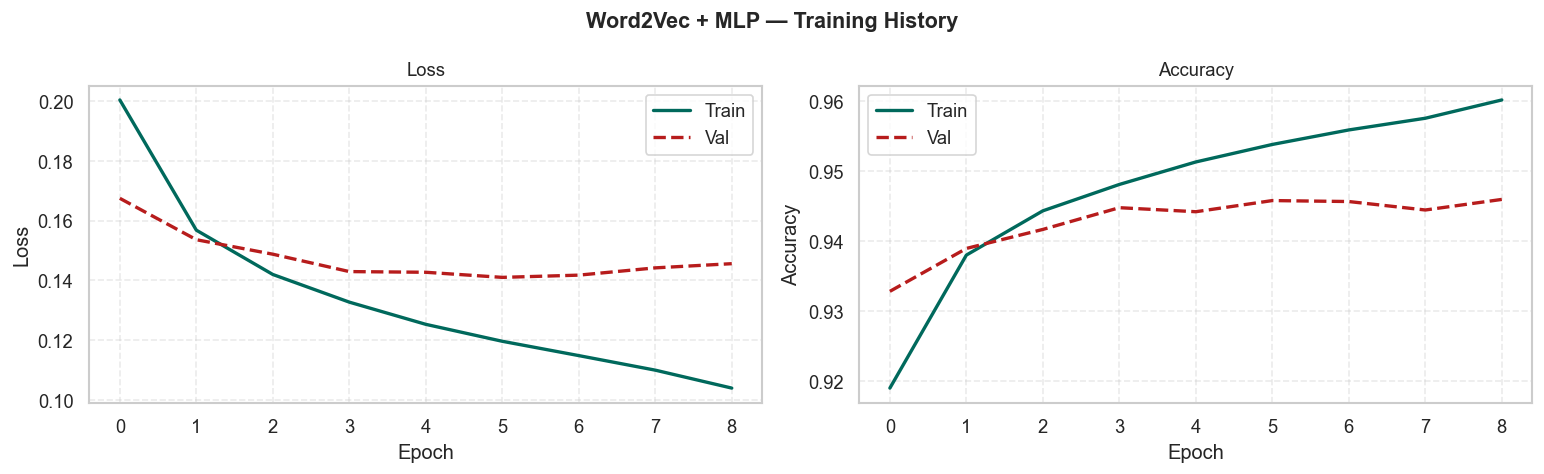

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Word2Vec + MLP — Training History', fontsize=13, fontweight='bold')
for ax, (metric, val_metric, ylabel) in zip(axes, [
    ('loss', 'val_loss', 'Loss'),
    ('accuracy', 'val_accuracy', 'Accuracy')
]):
    ax.plot(history_w2v.history[metric],     label='Train', color=COLOR_WORD2VEC, lw=2)
    ax.plot(history_w2v.history[val_metric], label='Val',   color=COLOR_NEGATIVE, lw=2, ls='--')
    ax.set_title(ylabel, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(ls='--', alpha=0.4)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 6. Model Comparison (Embedding Models)

In [49]:
exp_names_emb = ['GloVe + MLP', 'Word2Vec + MLP']

rows = []
for name in exp_names_emb:
    r = embedding_results[name]
    rows.append({
        'Experiment'    : name,
        'Accuracy'      : round(r['accuracy'],  4),
        'Precision'     : round(r['precision'], 4),
        'Recall'        : round(r['recall'],    4),
        'F1-macro'      : round(r['f1'],        4),
        'Train Time (s)': round(r['train_time'],1)
    })

df_emb = pd.DataFrame(rows).sort_values('F1-macro', ascending=False).reset_index(drop=True)
df_emb.index += 1
print(df_emb.to_string())

       Experiment  Accuracy  Precision  Recall  F1-macro  Train Time (s)
1  Word2Vec + MLP    0.9477     0.9089  0.8892    0.8986            54.6
2     GloVe + MLP    0.8895     0.8149  0.7238    0.7572            45.4


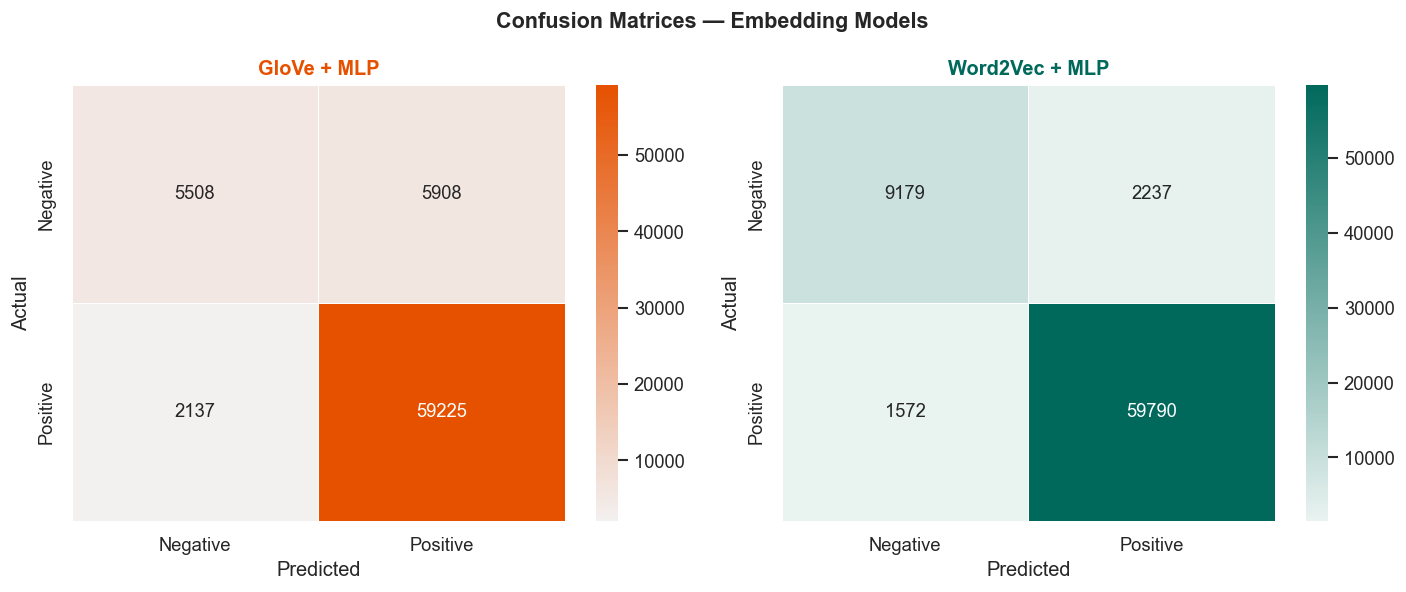

In [50]:
class_labels = ['Negative', 'Positive']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — Embedding Models', fontsize=13, fontweight='bold')

for idx, (name, color) in enumerate(zip(exp_names_emb, COLOR_EMBEDDING)):
    ax = axes[idx]
    cm = embedding_results[name]['cm']
    sns.heatmap(cm, annot=True, fmt='d',
                cmap=sns.light_palette(color, as_cmap=True),
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=0.5, ax=ax)
    ax.set_title(name, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

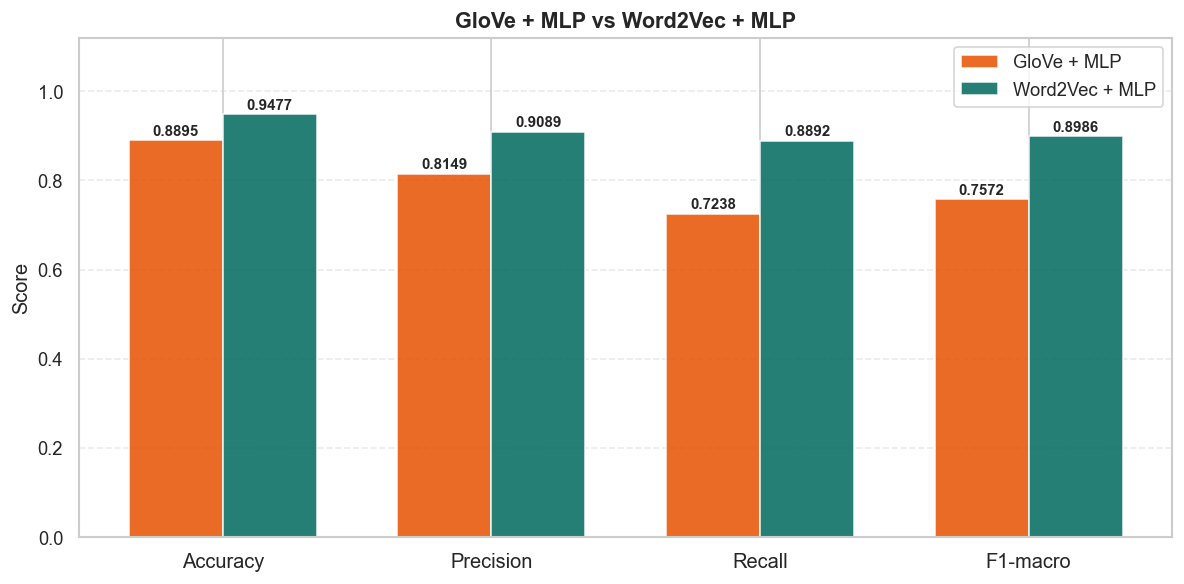

In [51]:
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-macro']
metric_keys = ['accuracy', 'precision', 'recall', 'f1']
bar_width   = 0.35
x = np.arange(len(metrics))

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, color) in enumerate(zip(exp_names_emb, COLOR_EMBEDDING)):
    values = [embedding_results[name][k] for k in metric_keys]
    offset = (i - 0.5) * bar_width
    bars = ax.bar(x + offset, values, width=bar_width, label=name, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('GloVe + MLP vs Word2Vec + MLP', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

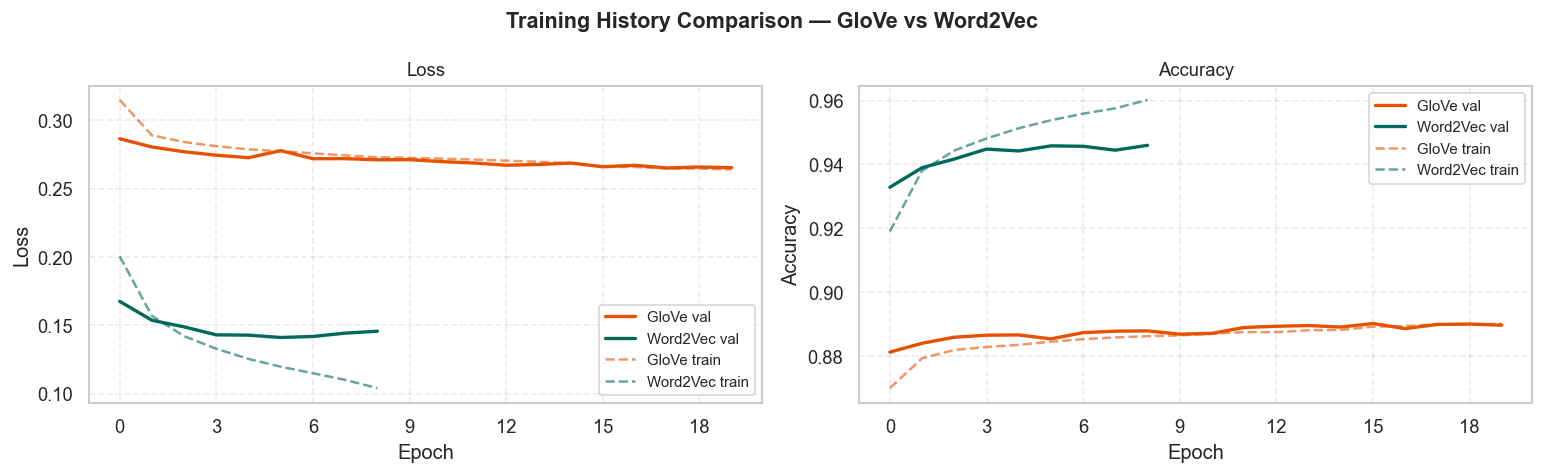

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training History Comparison — GloVe vs Word2Vec', fontsize=13, fontweight='bold')

for ax, (metric, val_metric, ylabel) in zip(axes, [
    ('loss', 'val_loss', 'Loss'),
    ('accuracy', 'val_accuracy', 'Accuracy')
]):
    ax.plot(history_glove.history[val_metric], label='GloVe val',    color=COLOR_GLOVE,    lw=2)
    ax.plot(history_w2v.history[val_metric],   label='Word2Vec val', color=COLOR_WORD2VEC, lw=2)
    ax.plot(history_glove.history[metric],     label='GloVe train',  color=COLOR_GLOVE,    lw=1.5, ls='--', alpha=0.6)
    ax.plot(history_w2v.history[metric],       label='Word2Vec train', color=COLOR_WORD2VEC, lw=1.5, ls='--', alpha=0.6)
    ax.set_title(ylabel, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(ls='--', alpha=0.4)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## 7. Save Artifacts

In [53]:
model_glove.save('model_glove_mlp.keras')
model_w2v.save('model_w2v_mlp.keras')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

w2v_model.save('word2vec.model')

print('✅ Saved: model_glove_mlp.keras, model_w2v_mlp.keras, tokenizer.pkl, word2vec.model')

✅ Saved: model_glove_mlp.keras, model_w2v_mlp.keras, tokenizer.pkl, word2vec.model


In [54]:
embedding_metrics = {}
for name, res in embedding_results.items():
    embedding_metrics[name] = {
        'accuracy'        : res['accuracy'],
        'precision'       : res['precision'],
        'recall'          : res['recall'],
        'f1'              : res['f1'],
        'confusion_matrix': res['cm'].tolist()
    }

with open('embedding_metrics.json', 'w') as f:
    json.dump(embedding_metrics, f, indent=2)

print('✅ Saved embedding_metrics.json')
print()

for fname in ['model_glove_mlp.keras','model_w2v_mlp.keras','tokenizer.pkl','word2vec.model','embedding_metrics.json']:
    if os.path.exists(fname):
        size_kb = os.path.getsize(fname) / 1024
        print(f'  {fname:<30} {size_kb:>8.1f} KB')
    else:
        print(f'  {fname:<30}  (directory/bundle)')

✅ Saved embedding_metrics.json

  model_glove_mlp.keras            4484.4 KB
  model_w2v_mlp.keras             12298.2 KB
  tokenizer.pkl                    8127.3 KB
  word2vec.model                  30246.5 KB
  embedding_metrics.json              0.6 KB


---
## ✅ Summary

| Artifact | Deskripsi |
|----------|-----------|
| `model_glove_mlp.keras` | GloVe + MLP Keras model |
| `model_w2v_mlp.keras` | Word2Vec + MLP Keras model |
| `tokenizer.pkl` | Fitted Keras Tokenizer |
| `word2vec.model` | Trained Gensim Word2Vec model |
| `embedding_metrics.json` | Metrics untuk dashboard |

**Next step →** `04_transformer.ipynb` (run di Kaggle)

# 04 — Transformer Model: DistilBERT Fine-Tuning
## Amazon Fine Food Reviews — NLP Sentiment Classification

| Setting | Value |
|---|---|
| Model | DistilBERT (distilbert-base-uncased) |
| Task | Binary sentiment classification (0=Negative, 1=Positive) |
| Max sequence length | 128 tokens (local) / 256 tokens (GPU) |
| Batch size | 16 (local CPU) / 32 (GPU) |
| Epochs | 3 |
| Learning rate | 2e-5 (AdamW + linear warmup) |
| Output | `transformer_metrics.json` |

---

## 1. Setup & Imports

In [55]:
import subprocess, sys
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '--quiet',
    'transformers', 'datasets', 'accelerate', 'torch', 'scikit-learn'
])

# Pre-download DistilBERT model & tokenizer to cache
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
print('Downloading DistilBERT tokenizer...')
DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
print('Downloading DistilBERT model weights...')
DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
print('✅ DistilBERT cached successfully.')


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ DistilBERT cached successfully.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json, os, time, warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print(f'PyTorch : {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

COLOR_POSITIVE    = '#1565C0'
COLOR_NEGATIVE    = '#B71C1C'
COLOR_TRANSFORMER = '#AD1457'

## 2. Load Data

> **LOCAL_RUN mode:** Menggunakan subset kecil agar bisa selesai dalam waktu wajar di CPU.
> Set `LOCAL_RUN = False` jika kamu punya GPU (CUDA) untuk melatih dengan data penuh.

> **Kenapa `Review_Text` bukan `Cleaned_Text`?** DistilBERT menggunakan WordPiece tokenizer-nya sendiri
> yang menangani tanda baca, kapitalisasi, dan subword secara internal.

In [57]:
# ─────────────────────────────────────────────────────────────
#  KONFIGURASI — sesuaikan DATA_DIR sebelum run
# ─────────────────────────────────────────────────────────────
import os
from pathlib import Path

# ✏️  Ubah path ini ke folder yang berisi train.csv / val.csv / test.csv
# Contoh Windows : DATA_DIR = Path(r'C:\Users\Sueb\Desktop\nlp dashboard')
# Contoh macOS/Linux: DATA_DIR = Path.home() / 'data' / 'nlp_dashboard'
DATA_DIR = Path(r'C:\Users\Sueb\Desktop\nlp dashboard')  # ← sesuaikan ini

print(f'DATA_DIR : {DATA_DIR}')
assert DATA_DIR.exists(), f'❌ Folder tidak ditemukan: {DATA_DIR}'
assert (DATA_DIR / 'train.csv').exists(), f'❌ train.csv tidak ada di {DATA_DIR}'
assert (DATA_DIR / 'val.csv').exists(),   f'❌ val.csv tidak ada di {DATA_DIR}'
assert (DATA_DIR / 'test.csv').exists(),  f'❌ test.csv tidak ada di {DATA_DIR}'
print('✅ Semua path valid.')

# LOCAL_RUN = True  → subset kecil, cocok CPU/laptop
# LOCAL_RUN = False → dataset penuh, butuh GPU
import torch
LOCAL_RUN = not torch.cuda.is_available()  # otomatis deteksi

if LOCAL_RUN:
    SAMPLE_TRAIN = 5_000
    SAMPLE_VAL   = 1_000
    SAMPLE_TEST  = 1_000
    MAX_LEN      = 128
    BATCH_SIZE   = 16
    EPOCHS       = 2
    print('⚡ LOCAL_RUN mode: data subset, MAX_LEN=128, BATCH=16, EPOCHS=2')
else:
    SAMPLE_TRAIN = None
    SAMPLE_VAL   = None
    SAMPLE_TEST  = None
    MAX_LEN      = 256
    BATCH_SIZE   = 32
    EPOCHS       = 3
    print('🚀 GPU mode: full dataset, MAX_LEN=256, BATCH=32, EPOCHS=3')


DATA_DIR : C:\Users\Sueb\Desktop\nlp dashboard
✅ Semua path valid.
🚀 GPU mode: full dataset, MAX_LEN=256, BATCH=32, EPOCHS=3


In [58]:
def load_split(filename, nrows=None):
    path = DATA_DIR / filename
    df = pd.read_csv(path, nrows=nrows)
    df['Review_Text'] = df['Review_Text'].fillna('')
    return df

df_train = load_split('train.csv',  SAMPLE_TRAIN)
df_val   = load_split('val.csv',    SAMPLE_VAL)
df_test  = load_split('test.csv',   SAMPLE_TEST)

X_train, y_train = df_train['Review_Text'].tolist(), df_train['Label'].tolist()
X_val,   y_val   = df_val['Review_Text'].tolist(),   df_val['Label'].tolist()
X_test,  y_test  = df_test['Review_Text'].tolist(),  df_test['Label'].tolist()

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')
print()
for name, labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    arr = np.array(labels)
    pos = arr.sum()
    neg = len(arr) - pos
    print(f'  {name:5s} — Positive: {pos:,} ({pos/len(arr)*100:.1f}%)  Negative: {neg:,} ({neg/len(arr)*100:.1f}%)')


Train : 254,721  |  Val : 36,389  |  Test : 72,778

  Train — Positive: 214,764 (84.3%)  Negative: 39,957 (15.7%)
  Val   — Positive: 30,681 (84.3%)  Negative: 5,708 (15.7%)
  Test  — Positive: 61,362 (84.3%)  Negative: 11,416 (15.7%)


## 3. Tokenization

`MAX_LEN = 128` untuk local CPU (DistilBERT support up to 512 tokens).

In [59]:
MODEL_NAME = 'distilbert-base-uncased'

tokenizer_bert = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print(f'Tokenizer: {MODEL_NAME}')
print(f'Vocab size: {tokenizer_bert.vocab_size:,}')

Tokenizer: distilbert-base-uncased
Vocab size: 30,522


In [60]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            texts, truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

In [61]:
# num_workers=0 wajib di Windows untuk menghindari multiprocessing error
NUM_WORKERS = 0

print('Tokenizing datasets (mungkin beberapa menit)...')
train_dataset = SentimentDataset(X_train, y_train, tokenizer_bert, MAX_LEN)
val_dataset   = SentimentDataset(X_val,   y_val,   tokenizer_bert, MAX_LEN)
test_dataset  = SentimentDataset(X_test,  y_test,  tokenizer_bert, MAX_LEN)
print('Done.')

pin = device.type == 'cuda'  # pin_memory hanya efektif di GPU
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)

print(f'Train batches: {len(train_loader):,}  |  Val: {len(val_loader):,}  |  Test: {len(test_loader):,}')


Tokenizing datasets (mungkin beberapa menit)...
Done.
Train batches: 7,961  |  Val: 1,138  |  Test: 2,275


## 4. Model Setup

- **AdamW** dengan weight decay 0.01 — standar untuk BERT fine-tuning
- **Linear warmup** untuk 10% pertama steps, lalu linear decay ke 0
- **Gradient clipping** max norm 1.0 untuk mencegah exploding gradients

In [62]:
LR           = 2e-5
WARMUP_RATIO = 0.1

model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = model.to(device)

optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f'Model parameters     : {sum(p.numel() for p in model.parameters()):,}')
print(f'Total training steps : {total_steps:,}')
print(f'Warmup steps         : {warmup_steps:,}')


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters     : 66,955,010
Total training steps : 23,883
Warmup steps         : 2,388


## 5. Training Loop

In [63]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for i, batch in enumerate(loader):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbl  = batch['labels'].to(device)
        optimizer.zero_grad()
        out  = model(input_ids=ids, attention_mask=mask, labels=lbl)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += out.loss.item()
        all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
        all_labels.extend(lbl.cpu().numpy())
        if (i + 1) % 50 == 0:
            print(f'    Batch {i+1}/{len(loader)}  loss={out.loss.item():.4f}')
    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbl  = batch['labels'].to(device)
            out  = model(input_ids=ids, attention_mask=mask, labels=lbl)
            total_loss += out.loss.item()
            all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
            all_labels.extend(lbl.cpu().numpy())
    return total_loss / len(loader), accuracy_score(all_labels, all_preds), all_preds, all_labels

In [64]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss, best_epoch = float('inf'), 0
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f'Epoch {epoch}/{EPOCHS}')
    t0 = time.time()
    train_loss, train_acc       = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, _, _     = eval_epoch(model, val_loader, device)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    print(f'  Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}')
    print(f'  Val   Loss: {val_loss:.4f}  Acc: {val_acc:.4f}')
    print(f'  Time: {time.time()-t0:.1f}s')
    if val_loss < best_val_loss:
        best_val_loss, best_epoch = val_loss, epoch
        model.save_pretrained('./best_distilbert')
        tokenizer_bert.save_pretrained('./best_distilbert')
        print(f'  ✅ Checkpoint saved (val_loss={best_val_loss:.4f})')
    print()

total_train_time = time.time() - t_start
print(f'Total time : {total_train_time:.1f}s  ({total_train_time/60:.1f} min)')
print(f'Best epoch : {best_epoch}  (val_loss={best_val_loss:.4f})')

Epoch 1/3
    Batch 50/7961  loss=0.6698
    Batch 100/7961  loss=0.5821
    Batch 150/7961  loss=0.4170
    Batch 200/7961  loss=0.3828
    Batch 250/7961  loss=0.4663
    Batch 300/7961  loss=0.2872
    Batch 350/7961  loss=0.2143
    Batch 400/7961  loss=0.2879
    Batch 450/7961  loss=0.1037
    Batch 500/7961  loss=0.2684
    Batch 550/7961  loss=0.2002
    Batch 600/7961  loss=0.1560
    Batch 650/7961  loss=0.1285
    Batch 700/7961  loss=0.2341
    Batch 750/7961  loss=0.2517
    Batch 800/7961  loss=0.1171
    Batch 850/7961  loss=0.0327
    Batch 900/7961  loss=0.1126
    Batch 950/7961  loss=0.0344
    Batch 1000/7961  loss=0.1273
    Batch 1050/7961  loss=0.2064
    Batch 1100/7961  loss=0.0126
    Batch 1150/7961  loss=0.0207
    Batch 1200/7961  loss=0.0604
    Batch 1250/7961  loss=0.0334
    Batch 1300/7961  loss=0.2150
    Batch 1350/7961  loss=0.1410
    Batch 1400/7961  loss=0.1287
    Batch 1450/7961  loss=0.0301
    Batch 1500/7961  loss=0.1626
    Batch 1550/7961 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Checkpoint saved (val_loss=0.0719)

Epoch 2/3
    Batch 50/7961  loss=0.0252
    Batch 100/7961  loss=0.0622
    Batch 150/7961  loss=0.0962
    Batch 200/7961  loss=0.0927
    Batch 250/7961  loss=0.0527
    Batch 300/7961  loss=0.0369
    Batch 350/7961  loss=0.0174
    Batch 400/7961  loss=0.0162
    Batch 450/7961  loss=0.1428
    Batch 500/7961  loss=0.0162
    Batch 550/7961  loss=0.0259
    Batch 600/7961  loss=0.0078
    Batch 650/7961  loss=0.1483
    Batch 700/7961  loss=0.0021
    Batch 750/7961  loss=0.0107
    Batch 800/7961  loss=0.0055
    Batch 850/7961  loss=0.0682
    Batch 900/7961  loss=0.0162
    Batch 950/7961  loss=0.0336
    Batch 1000/7961  loss=0.0188
    Batch 1050/7961  loss=0.0036
    Batch 1100/7961  loss=0.0613
    Batch 1150/7961  loss=0.0375
    Batch 1200/7961  loss=0.0044
    Batch 1250/7961  loss=0.0057
    Batch 1300/7961  loss=0.0053
    Batch 1350/7961  loss=0.2079
    Batch 1400/7961  loss=0.1896
    Batch 1450/7961  loss=0.0102
    Batch 150

## 6. Evaluation on Test Set

In [65]:
best_model = DistilBertForSequenceClassification.from_pretrained('./best_distilbert')
best_model = best_model.to(device)
print(f'Loaded best checkpoint (epoch {best_epoch})')

_, _, y_pred_list, y_true_list = eval_epoch(best_model, test_loader, device)
y_pred = np.array(y_pred_list)
y_true = np.array(y_true_list)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('Test Set Results')
print('=' * 40)
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}  (macro)')
print(f'Recall    : {rec:.4f}  (macro)')
print(f'F1-macro  : {f1:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=['Negative','Positive'], zero_division=0))


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded best checkpoint (epoch 1)
Test Set Results
Accuracy  : 0.9739
Precision : 0.9454  (macro)
Recall    : 0.9576  (macro)
F1-macro  : 0.9513

              precision    recall  f1-score   support

    Negative       0.90      0.93      0.92     11416
    Positive       0.99      0.98      0.98     61362

    accuracy                           0.97     72778
   macro avg       0.95      0.96      0.95     72778
weighted avg       0.97      0.97      0.97     72778



## 7. Visualizations

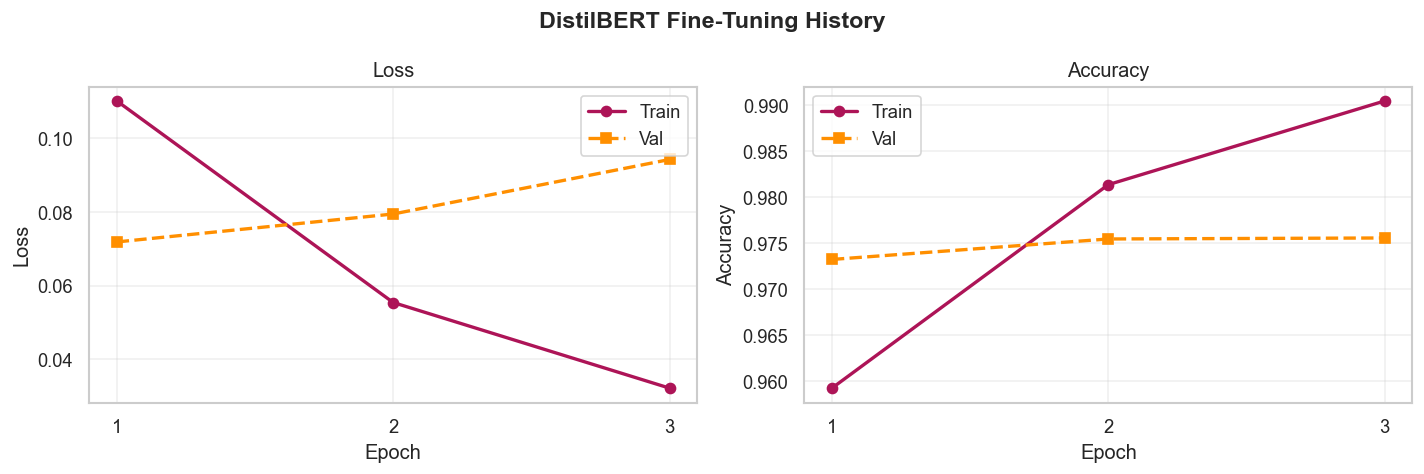

In [66]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('DistilBERT Fine-Tuning History', fontsize=14, fontweight='bold')

for ax, (metric, val_metric, ylabel) in zip(axes, [
    ('train_loss', 'val_loss', 'Loss'),
    ('train_acc',  'val_acc',  'Accuracy')
]):
    ax.plot(epochs_range, history[metric],     'o-', color=COLOR_TRANSFORMER, label='Train', lw=2, ms=6)
    ax.plot(epochs_range, history[val_metric], 's--', color='#FF8F00',        label='Val',   lw=2, ms=6)
    ax.set_title(ylabel)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./distilbert_history.png', dpi=150, bbox_inches='tight')
plt.show()

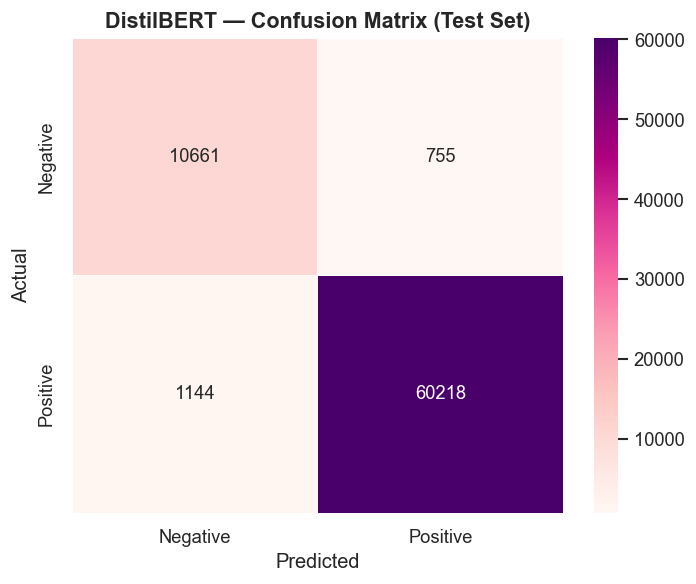

In [67]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'],
            linewidths=0.5, ax=ax)
ax.set_title('DistilBERT — Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('./distilbert_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Results

Metrics disimpan dengan format yang sama seperti `classical_metrics.json` dan `embedding_metrics.json`
sehingga `05_comparison.ipynb` bisa memuat dan membandingkan semua model.

In [68]:
transformer_results = {
    'DistilBERT': {
        'accuracy'        : float(acc),
        'precision'       : float(prec),
        'recall'          : float(rec),
        'f1'              : float(f1),
        'confusion_matrix': cm.tolist(),
        'train_time_s'    : total_train_time,
        'epochs'          : EPOCHS,
        'model_name'      : MODEL_NAME
    }
}

output_path = DATA_DIR / 'transformer_metrics.json'
with open(output_path, 'w') as fout:
    json.dump(transformer_results, fout, indent=2)

print(f'✅ Saved {output_path}')
print()
print('Sekarang jalankan 05_comparison.ipynb untuk membandingkan semua model.')


✅ Saved C:\Users\Sueb\Desktop\nlp dashboard\transformer_metrics.json

Sekarang jalankan 05_comparison.ipynb untuk membandingkan semua model.


In [69]:
# Print JSON — copy-paste jika diperlukan
print('transformer_metrics.json:')
print(json.dumps(transformer_results, indent=2))

transformer_metrics.json:
{
  "DistilBERT": {
    "accuracy": 0.9739069499024431,
    "precision": 0.9453546901176282,
    "recall": 0.9576106455522246,
    "f1": 0.9513488134619775,
    "confusion_matrix": [
      [
        10661,
        755
      ],
      [
        1144,
        60218
      ]
    ],
    "train_time_s": 5135.981457233429,
    "epochs": 3,
    "model_name": "distilbert-base-uncased"
  }
}


---
## ✅ Summary

| Artifact | Path |
|----------|------|
| Best model weights | `./best_distilbert/` |
| Training history plot | `./distilbert_history.png` |
| Confusion matrix plot | `./distilbert_cm.png` |
| **Metrics JSON** | `./transformer_metrics.json` |

**Next step:** Jalankan **`05_comparison.ipynb`** untuk membandingkan semua 9 model.

# 05 — Model Comparison: All Experiments
## Amazon Fine Food Reviews — NLP Sentiment Classification

Notebook ini menggabungkan hasil dari semua eksperimen dan membandingkan performa seluruh model.

| Sumber | File | Model |
|--------|------|-------|
| `02_classical_models.ipynb` | `classical_metrics.json` | DT+BOW, DT+N-Gram, DT+TF-IDF, NB+BOW, NB+N-Gram, NB+TF-IDF |
| `03_embedding_models.ipynb` | `embedding_metrics.json` | GloVe+MLP, Word2Vec+MLP |
| `04_transformer.ipynb` (Kaggle) | `transformer_metrics.json` | DistilBERT *(opsional)* |

> **Catatan:** Notebook ini berjalan dengan 6 atau 8 model jika `transformer_metrics.json` belum tersedia.
> Tambahkan file tersebut kapan saja dan jalankan ulang untuk mendapatkan perbandingan 9 model.

---

## 1. Setup & Imports

In [47]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 30)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')

# Color palette — consistent across all notebooks
COLOR_DT_BOW    = '#1B5E20'
COLOR_DT_NGRAM  = '#388E3C'
COLOR_DT_TFIDF  = '#81C784'
COLOR_NB_BOW    = '#4A148C'
COLOR_NB_NGRAM  = '#7B1FA2'
COLOR_NB_TFIDF  = '#CE93D8'
COLOR_GLOVE     = '#E65100'
COLOR_WORD2VEC  = '#00695C'
COLOR_DISTILBERT= '#AD1457'

ALL_COLORS = [
    COLOR_DT_BOW, COLOR_DT_NGRAM, COLOR_DT_TFIDF,
    COLOR_NB_BOW, COLOR_NB_NGRAM, COLOR_NB_TFIDF,
    COLOR_GLOVE, COLOR_WORD2VEC, COLOR_DISTILBERT
]

print('✅ Setup complete.')

✅ Setup complete.


## 2. Load All Metrics

In [48]:
all_metrics = {}

# Load classical metrics (required)
with open('classical_metrics.json') as f:
    all_metrics.update(json.load(f))
print(f'Loaded classical_metrics.json  : {len(all_metrics)} models')

# Load embedding metrics (required)
with open('embedding_metrics.json') as f:
    all_metrics.update(json.load(f))
print(f'Loaded embedding_metrics.json  : {len(all_metrics)} models total')

# Load transformer metrics (optional — from Kaggle)
if os.path.exists('transformer_metrics.json'):
    with open('transformer_metrics.json') as f:
        all_metrics.update(json.load(f))
    print(f'Loaded transformer_metrics.json: {len(all_metrics)} models total')
else:
    print('transformer_metrics.json not found — running with', len(all_metrics), 'models')
    print('(Add transformer_metrics.json from Kaggle and re-run for 9-model comparison)')

print()
print('Models loaded:')
for i, name in enumerate(all_metrics, 1):
    print(f'  {i:2d}. {name}')

Loaded classical_metrics.json  : 6 models
Loaded embedding_metrics.json  : 8 models total
Loaded transformer_metrics.json: 9 models total

Models loaded:
   1. DT + BOW
   2. DT + N-Gram
   3. DT + TF-IDF
   4. NB + BOW
   5. NB + N-Gram
   6. NB + TF-IDF
   7. GloVe + MLP
   8. Word2Vec + MLP
   9. DistilBERT


## 3. Summary Table

In [49]:
rows = []
for name, res in all_metrics.items():
    rows.append({
        'Model'     : name,
        'Accuracy'  : round(res['accuracy'],  4),
        'Precision' : round(res['precision'], 4),
        'Recall'    : round(res['recall'],    4),
        'F1-macro'  : round(res['f1'],        4),
    })

df_all = pd.DataFrame(rows).sort_values('F1-macro', ascending=False).reset_index(drop=True)
df_all.index += 1

print('All Models — Sorted by F1-macro (descending)')
print('=' * 65)
print(df_all.to_string())
print()

best_name = df_all.iloc[0]['Model']
best_f1   = df_all.iloc[0]['F1-macro']
best_acc  = df_all.iloc[0]['Accuracy']
print(f'🏆 Best model : {best_name}')
print(f'   F1-macro   : {best_f1:.4f}')
print(f'   Accuracy   : {best_acc:.4f}')

All Models — Sorted by F1-macro (descending)
            Model  Accuracy  Precision  Recall  F1-macro
1      DistilBERT    0.9739     0.9454  0.9576    0.9513
2  Word2Vec + MLP    0.9477     0.9089  0.8892    0.8986
3     NB + N-Gram    0.9087     0.8155  0.9062    0.8500
4        NB + BOW    0.9017     0.8053  0.8930    0.8385
5     NB + TF-IDF    0.8911     0.7904  0.8857    0.8247
6     GloVe + MLP    0.8895     0.8149  0.7238    0.7572
7     DT + N-Gram    0.8386     0.7236  0.8193    0.7522
8        DT + BOW    0.8297     0.7144  0.8118    0.7419
9     DT + TF-IDF    0.8195     0.7059  0.8083    0.7322

🏆 Best model : DistilBERT
   F1-macro   : 0.9513
   Accuracy   : 0.9739


## 4. Visualizations

### 4.1 F1-macro Ranking (Horizontal Bar)

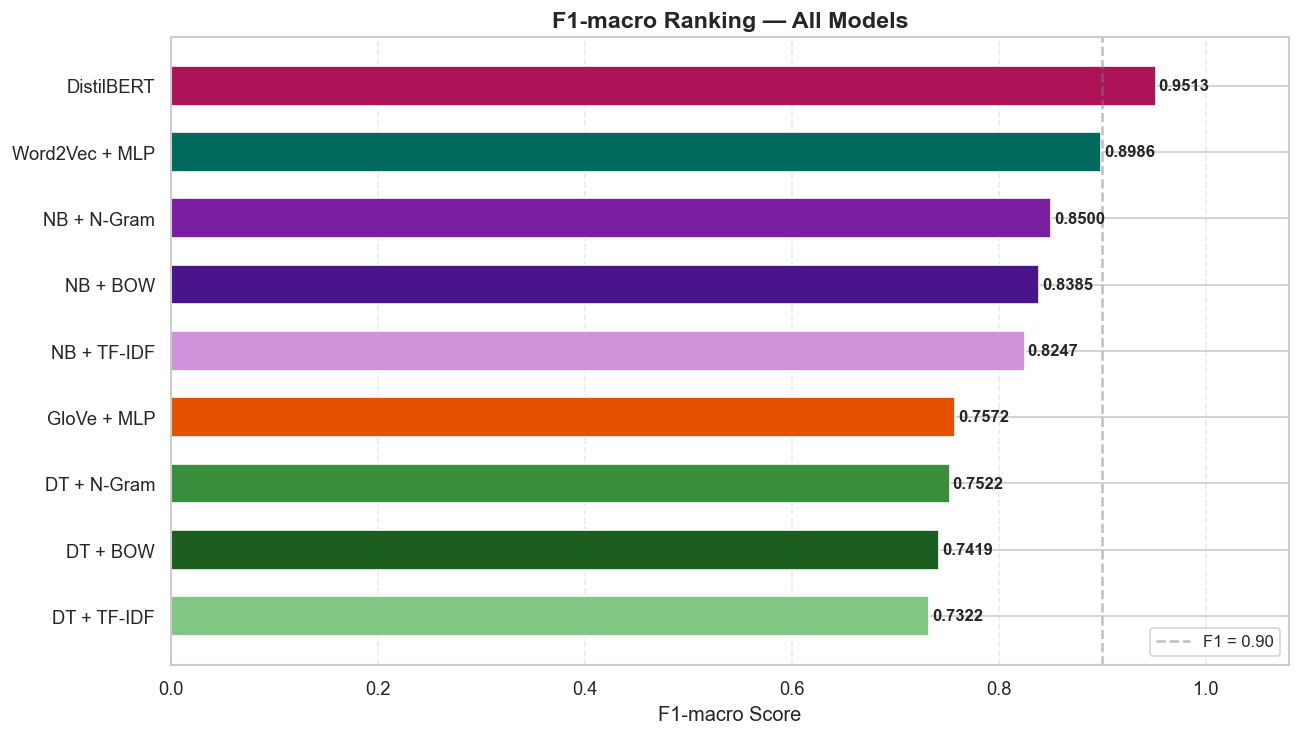

In [50]:
exp_names = list(all_metrics.keys())
colors    = ALL_COLORS[:len(exp_names)]

# Sort by F1 ascending for horizontal bar
sorted_data = sorted(
    [(name, all_metrics[name]['f1'], colors[i]) for i, name in enumerate(exp_names)],
    key=lambda x: x[1]
)
names_s  = [d[0] for d in sorted_data]
f1_s     = [d[1] for d in sorted_data]
colors_s = [d[2] for d in sorted_data]

fig, ax = plt.subplots(figsize=(11, max(5, len(exp_names)*0.7)))
bars = ax.barh(names_s, f1_s, color=colors_s, edgecolor='white', height=0.6)

for bar, val in zip(bars, f1_s):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_xlim(0, 1.08)
ax.set_xlabel('F1-macro Score', fontsize=12)
ax.set_title('F1-macro Ranking — All Models', fontsize=14, fontweight='bold')
ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.5, label='F1 = 0.90')
ax.legend(fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('comparison_f1_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Grouped Bar — All 4 Metrics

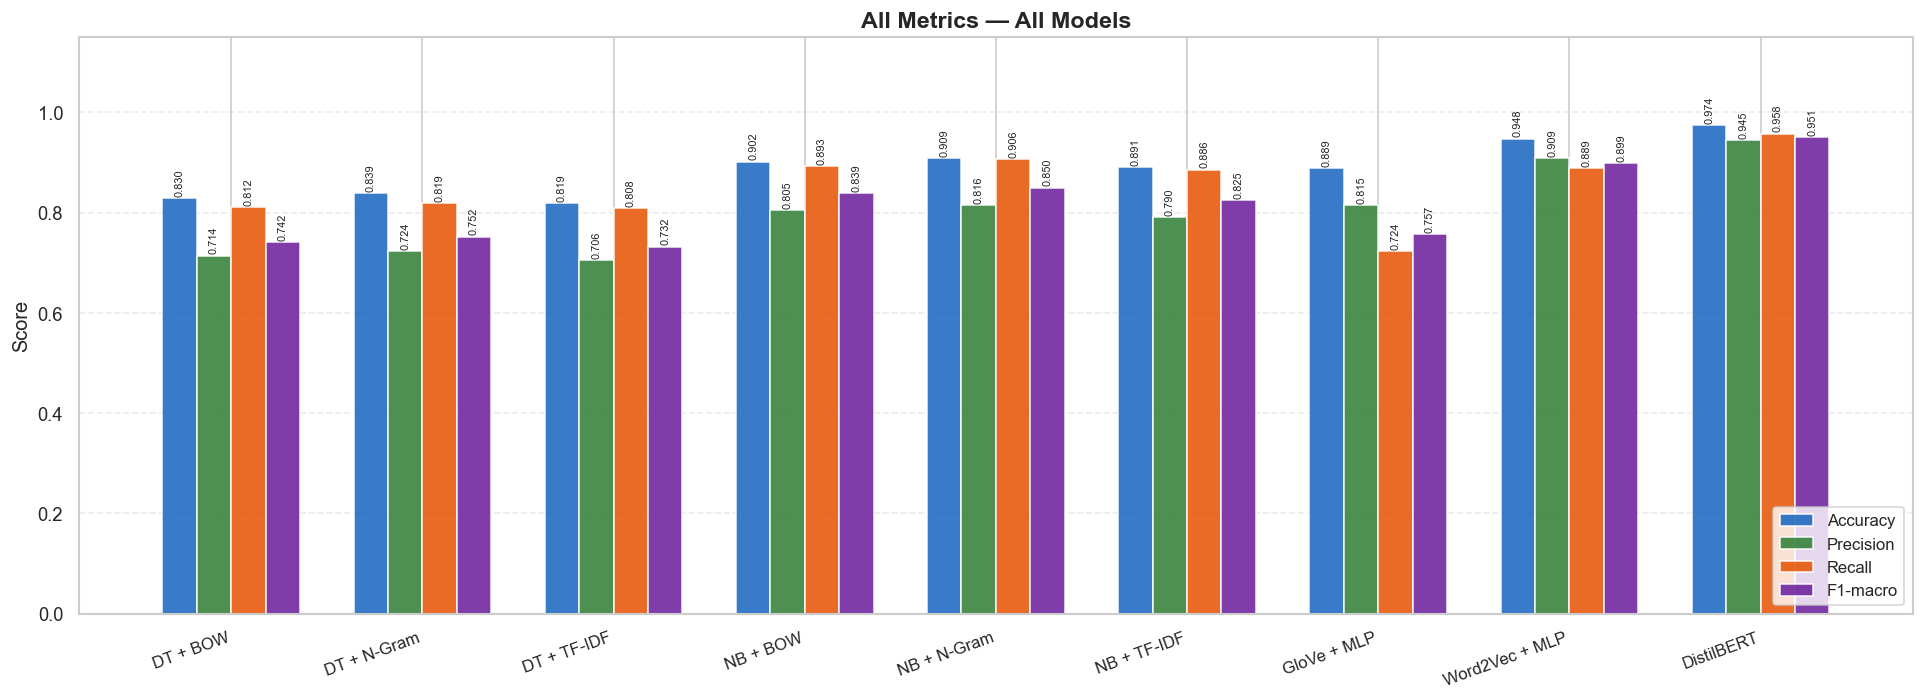

In [51]:
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-macro']
metric_keys = ['accuracy', 'precision', 'recall', 'f1']
metric_colors = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']

n_exp    = len(exp_names)
bar_w    = 0.18
x        = np.arange(n_exp)
offsets  = np.linspace(-(len(metrics)-1)/2, (len(metrics)-1)/2, len(metrics)) * bar_w

fig, ax = plt.subplots(figsize=(max(14, n_exp*1.8), 6))

for i, (metric, key, mc) in enumerate(zip(metrics, metric_keys, metric_colors)):
    values = [all_metrics[name][key] for name in exp_names]
    bars   = ax.bar(x + offsets[i], values, width=bar_w, label=metric, color=mc, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{val:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(exp_names, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Metrics — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('comparison_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Radar Chart

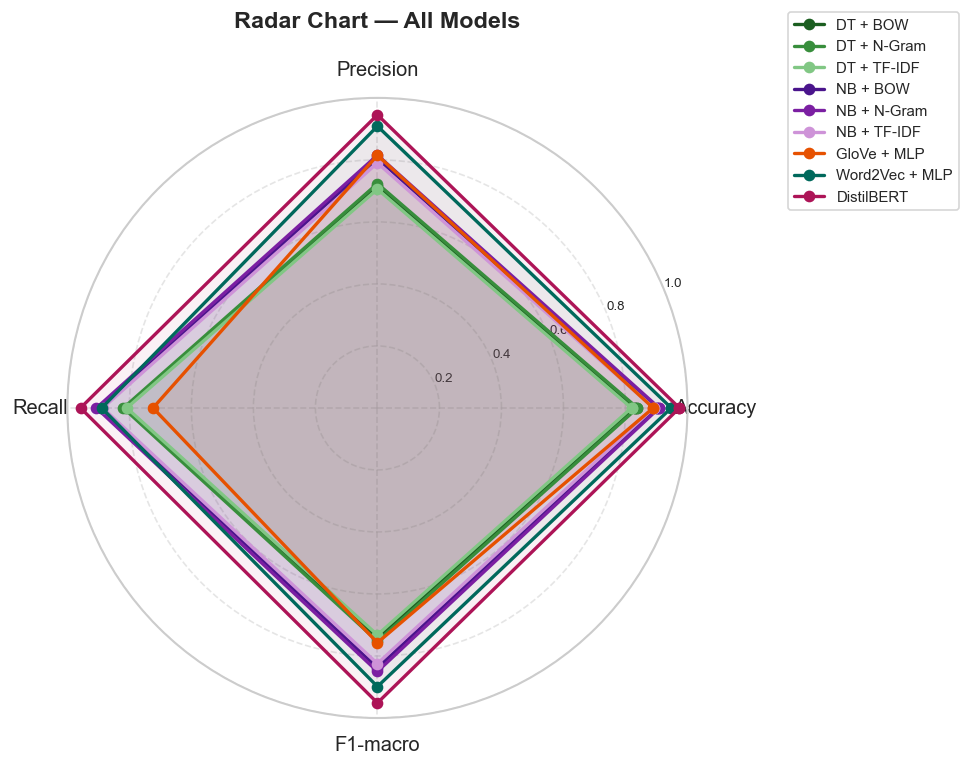

In [52]:
radar_keys   = ['accuracy', 'precision', 'recall', 'f1']
radar_labels = ['Accuracy', 'Precision', 'Recall', 'F1-macro']
N = len(radar_labels)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for name, color in zip(exp_names, colors):
    values = [all_metrics[name][k] for k in radar_keys] + [all_metrics[name][radar_keys[0]]]
    ax.plot(angles, values, 'o-', lw=2, color=color, label=name)
    ax.fill(angles, values, alpha=0.06, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8)
ax.set_title('Radar Chart — All Models', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('comparison_radar.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Confusion Matrices — All Models

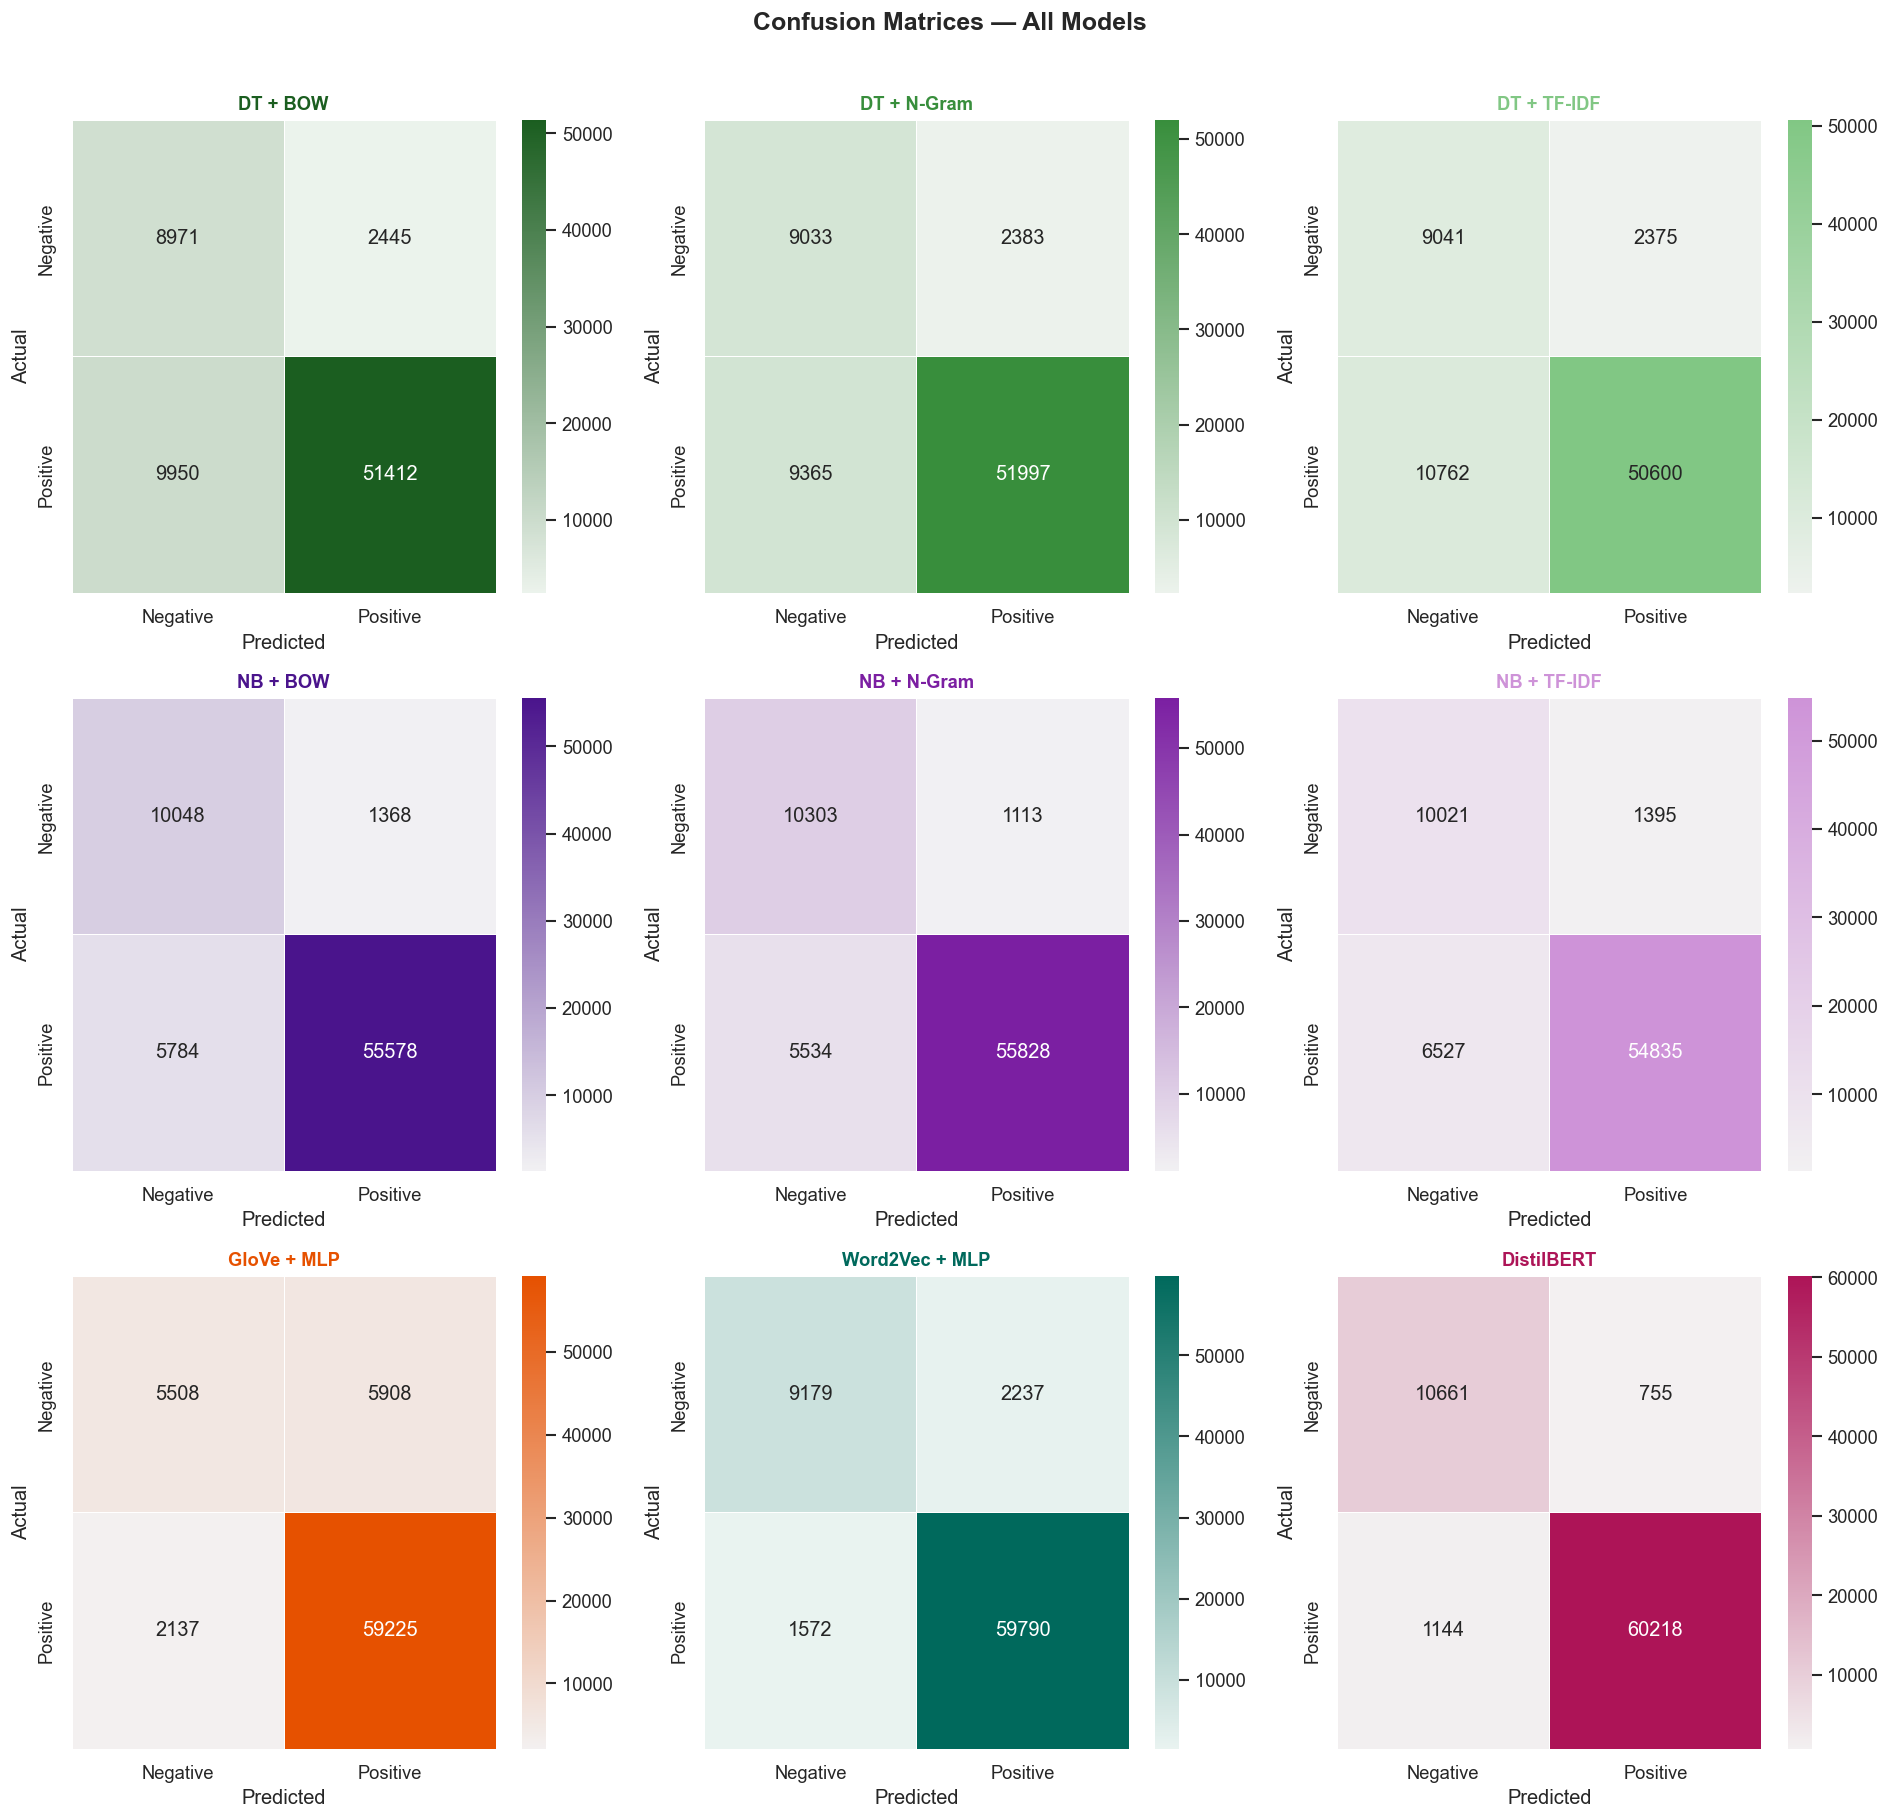

In [53]:
n_models = len(exp_names)
n_cols   = 3
n_rows   = (n_models + n_cols - 1) // n_cols
class_labels = ['Negative', 'Positive']

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes_flat = axes.flatten() if n_rows > 1 else axes

for idx, (name, color) in enumerate(zip(exp_names, colors)):
    ax = axes_flat[idx]
    cm = np.array(all_metrics[name]['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d',
                cmap=sns.light_palette(color, as_cmap=True),
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=0.5, ax=ax)
    ax.set_title(name, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Hide unused subplots
for idx in range(n_models, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comparison_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Best Model Analysis

In [54]:
best_name = df_all.iloc[0]['Model']
best_res  = all_metrics[best_name]
cm        = np.array(best_res['confusion_matrix'])

tn, fp = cm[0][0], cm[0][1]
fn, tp = cm[1][0], cm[1][1]
total  = cm.sum()

print(f'Best Model: {best_name}')
print('=' * 50)
print(f'  Accuracy  : {best_res["accuracy"]:.4f}')
print(f'  Precision : {best_res["precision"]:.4f}  (macro)')
print(f'  Recall    : {best_res["recall"]:.4f}  (macro)')
print(f'  F1-macro  : {best_res["f1"]:.4f}')
print()
print('Confusion Matrix breakdown:')
print(f'  True Negative  (TN): {tn:,}  — Negative correctly identified')
print(f'  False Positive (FP): {fp:,}  — Negative misclassified as Positive')
print(f'  False Negative (FN): {fn:,}  — Positive misclassified as Negative')
print(f'  True Positive  (TP): {tp:,}  — Positive correctly identified')
print()
print(f'  Negative Recall (Sensitivity): {tn/(tn+fp):.4f}')
print(f'  Positive Recall (Sensitivity): {tp/(tp+fn):.4f}')

Best Model: DistilBERT
  Accuracy  : 0.9739
  Precision : 0.9454  (macro)
  Recall    : 0.9576  (macro)
  F1-macro  : 0.9513

Confusion Matrix breakdown:
  True Negative  (TN): 10,661  — Negative correctly identified
  False Positive (FP): 755  — Negative misclassified as Positive
  False Negative (FN): 1,144  — Positive misclassified as Negative
  True Positive  (TP): 60,218  — Positive correctly identified

  Negative Recall (Sensitivity): 0.9339
  Positive Recall (Sensitivity): 0.9814


## 6. Save all_metrics.json (for Dashboard)

In [17]:
# Save combined metrics for the Flask dashboard
with open('all_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)

print('✅ Saved all_metrics.json')
print(f'   Models included: {len(all_metrics)}')
for name in all_metrics:
    print(f'   - {name}')

✅ Saved all_metrics.json
   Models included: 9
   - DT + BOW
   - DT + N-Gram
   - DT + TF-IDF
   - NB + BOW
   - NB + N-Gram
   - NB + TF-IDF
   - GloVe + MLP
   - Word2Vec + MLP
   - DistilBERT


---
## ✅ Summary

| Artifact | Deskripsi |
|----------|-----------|
| `all_metrics.json` | Semua metrics untuk Flask dashboard |
| `comparison_f1_ranking.png` | F1-macro ranking horizontal bar |
| `comparison_all_metrics.png` | Grouped bar semua metrik |
| `comparison_radar.png` | Radar chart semua model |
| `comparison_confusion_matrices.png` | Grid confusion matrix |

**Next step:** Jalankan `app.py` untuk melihat dashboard dengan semua model.

# 06 — Data Augmentation: Back Translation
## Amazon Fine Food Reviews — NLP Sentiment Classification

**Tujuan:** Menangani class imbalance (Negative: 15.69% vs Positive: 84.31%) dengan Back Translation  
**Strategi:** Augmentasi kelas Negative menggunakan dua bahasa perantara (Mandarin ZH + Jerman DE)  
**Target:** Meningkatkan jumlah sampel Negative dari ~57k → ~100k+

---

## 1. Setup & Imports

## Setup GPU & Model Translasi (MarianMT)

Bagian ini menggunakan model translasi lokal dari HuggingFace Transformers yang berjalan di GPU (CUDA).
Install dengan: `!pip install transformers sentencepiece torch`

In [5]:
import subprocess, sys

# Install dependencies
try:
    import torch
    from transformers import MarianMTModel, MarianTokenizer
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           'torch', 'transformers', 'sentencepiece', '--quiet'])
    import torch
    from transformers import MarianMTModel, MarianTokenizer

import pandas as pd
import numpy as np
import time
import json
import os
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

# Deteksi GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Libraries loaded.')
print(f'Device: {device}')

✅ Libraries loaded.
Device: cuda


## 2. Load Data & Analisis Class Imbalance

In [6]:
# Load training data
df_train = pd.read_csv('train.csv')
df_val   = pd.read_csv('val.csv')
df_test  = pd.read_csv('test.csv')

# Fill NaN
for df in [df_train, df_val, df_test]:
    df['Cleaned_Text'] = df['Cleaned_Text'].fillna('')

# Distribusi kelas
print('=== DISTRIBUSI KELAS ===')
print()
for name, df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    vc = df['Label'].value_counts()
    total = len(df)
    neg = vc.get(0, 0)
    pos = vc.get(1, 0)
    print(f'{name} ({total:,} total):')
    print(f'  Negative (0): {neg:,} ({neg/total*100:.1f}%)')
    print(f'  Positive (1): {pos:,} ({pos/total*100:.1f}%)')
    print(f'  Rasio imbalance: {pos/neg:.1f}x')
    print()

=== DISTRIBUSI KELAS ===

Train (254,721 total):
  Negative (0): 39,957 (15.7%)
  Positive (1): 214,764 (84.3%)
  Rasio imbalance: 5.4x

Val (36,389 total):
  Negative (0): 5,708 (15.7%)
  Positive (1): 30,681 (84.3%)
  Rasio imbalance: 5.4x

Test (72,778 total):
  Negative (0): 11,416 (15.7%)
  Positive (1): 61,362 (84.3%)
  Rasio imbalance: 5.4x



## 3. Back Translation Functions

**Skenario Back Translation:**
- EN → Mandarin (ZH) → EN : Paraphrase kuat karena struktur kalimat berbeda signifikan
- EN → Jerman (DE) → EN   : Variasi leksikal tinggi karena compound words dan grammar berbeda

**Referensi penelitian:**
> Sennrich et al. (2016) menunjukkan bahwa back-translation adalah teknik augmentasi yang efektif untuk meningkatkan variasi linguistik tanpa mengubah makna semantis teks.

In [7]:
# Load Model EN-DE
print('Loading EN-DE models...')
tok_en_de = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-de')
model_en_de = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-en-de').to(device)
tok_de_en = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-de-en')
model_de_en = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-de-en').to(device)

# Load Model EN-ZH
print('Loading EN-ZH models...')
tok_en_zh = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-zh')
model_en_zh = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-en-zh').to(device)
tok_zh_en = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-zh-en')
model_zh_en = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-zh-en').to(device)

print('✅ Semua model translasi berhasil di-load ke', device)

def back_translate(text, pivot_lang='zh-CN', max_length=512):
    """
    Back-translate teks dari EN -> pivot_lang -> EN menggunakan GPU.
    pivot_lang: 'zh-CN' atau 'de'
    """
    try:
        if pivot_lang == 'de':
            tok_fwd, model_fwd = tok_en_de, model_en_de
            tok_bwd, model_bwd = tok_de_en, model_de_en
        else:  # zh-CN
            tok_fwd, model_fwd = tok_en_zh, model_en_zh
            tok_bwd, model_bwd = tok_zh_en, model_zh_en

        # Forward: EN -> pivot
        inputs = tok_fwd(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
        translated = model_fwd.generate(**inputs)
        mid_text = tok_fwd.batch_decode(translated, skip_special_tokens=True)[0]

        # Backward: pivot -> EN
        inputs_back = tok_bwd(mid_text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
        back_translated = model_bwd.generate(**inputs_back)
        final_text = tok_bwd.batch_decode(back_translated, skip_special_tokens=True)[0]

        return final_text
    except Exception:
        return text

# Test
test_texts = [
    'This product is absolutely terrible and not worth the price at all.',
    'The taste was awful and the packaging was damaged when it arrived.',
]

print('\n=== TEST BACK TRANSLATION ===')
for i, text in enumerate(test_texts, 1):
    print(f'Contoh {i}:')
    print(f'  Original : {text}')
    bt_zh = back_translate(text, 'zh-CN')
    bt_de = back_translate(text, 'de')
    print(f'  BT-ZH    : {bt_zh}')
    print(f'  BT-DE    : {bt_de}')
    print()

Loading EN-DE models...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading EN-ZH models...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

✅ Semua model translasi berhasil di-load ke cuda

=== TEST BACK TRANSLATION ===
Contoh 1:
  Original : This product is absolutely terrible and not worth the price at all.
  BT-ZH    : Such products are absolutely terrible and worthless.
  BT-DE    : This product is absolutely terrible and not worth the price at all.

Contoh 2:
  Original : The taste was awful and the packaging was damaged when it arrived.
  BT-ZH    : The taste was too bad and the packaging was damaged when it arrived.
  BT-DE    : The taste was terrible and the packaging was damaged when it arrived.



## 4. Augmentasi Kelas Negative

**Strategi Augmentasi:**
1. Ambil semua sampel Negative dari training set
2. Buat versi back-translated (ZH dan DE) untuk setiap sampel
3. Filter sampel yang hasil translasi-nya berbeda dari aslinya
4. Gabungkan dengan dataset asli

In [8]:
# Ambil sampel Negative dari training set
df_negative = df_train[df_train['Label'] == 0].copy()
df_positive = df_train[df_train['Label'] == 1].copy()

print(f'Jumlah sampel Negative: {len(df_negative):,}')
print(f'Jumlah sampel Positive: {len(df_positive):,}')
print()

# Untuk demonstrasi, gunakan subset kecil (1000 sampel)
# Untuk augmentasi penuh, hapus baris '.head(1000)'
DEMO_MODE = True  # Set False untuk augmentasi penuh
SAMPLE_SIZE = 1000  # Jumlah sampel untuk demo

if DEMO_MODE:
    df_neg_sample = df_negative.sample(n=SAMPLE_SIZE, random_state=42)
    print(f'[DEMO MODE] Menggunakan {SAMPLE_SIZE} sampel dari {len(df_negative):,} sampel Negative')
    print('Untuk augmentasi penuh, set DEMO_MODE = False')
else:
    df_neg_sample = df_negative
    print(f'[FULL MODE] Menggunakan semua {len(df_negative):,} sampel Negative')

print()
print('Memulai back translation...')
print('(Ini mungkin memakan waktu beberapa menit)')

Jumlah sampel Negative: 39,957
Jumlah sampel Positive: 214,764

[DEMO MODE] Menggunakan 1000 sampel dari 39,957 sampel Negative
Untuk augmentasi penuh, set DEMO_MODE = False

Memulai back translation...
(Ini mungkin memakan waktu beberapa menit)


In [9]:
# Back Translation - Mandarin (ZH)
print('=== BACK TRANSLATION: EN → ZH → EN ===')

bt_zh_texts = []
bt_zh_valid = []

texts = df_neg_sample['Cleaned_Text'].tolist()

for i, text in enumerate(tqdm(texts, desc='ZH BT')):
    bt = back_translate(text, 'zh-CN')
    bt_zh_texts.append(bt)
    bt_zh_valid.append(bt.lower() != text.lower())  # True jika berbeda
    
    # Rate limiting - jangan terlalu cepat
    if (i + 1) % 50 == 0:
        time.sleep(1)

valid_zh = sum(bt_zh_valid)
print(f'\n✅ ZH Back Translation selesai!')
print(f'   Total: {len(bt_zh_texts):,}')
print(f'   Valid (berbeda dari aslinya): {valid_zh:,} ({valid_zh/len(texts)*100:.1f}%)')

=== BACK TRANSLATION: EN → ZH → EN ===


ZH BT: 100%|██████████| 1000/1000 [14:54<00:00,  1.12it/s]


✅ ZH Back Translation selesai!
   Total: 1,000
   Valid (berbeda dari aslinya): 1,000 (100.0%)


In [10]:
# Back Translation - German (DE)
print('=== BACK TRANSLATION: EN → DE → EN ===')

bt_de_texts = []
bt_de_valid = []

for i, text in enumerate(tqdm(texts, desc='DE BT')):
    bt = back_translate(text, 'de')
    bt_de_texts.append(bt)
    bt_de_valid.append(bt.lower() != text.lower())  # True jika berbeda
    
    # Rate limiting
    if (i + 1) % 50 == 0:
        time.sleep(1)

valid_de = sum(bt_de_valid)
print(f'\n✅ DE Back Translation selesai!')
print(f'   Total: {len(bt_de_texts):,}')
print(f'   Valid (berbeda dari aslinya): {valid_de:,} ({valid_de/len(texts)*100:.1f}%)')

=== BACK TRANSLATION: EN → DE → EN ===


DE BT: 100%|██████████| 1000/1000 [14:10<00:00,  1.18it/s]


✅ DE Back Translation selesai!
   Total: 1,000
   Valid (berbeda dari aslinya): 996 (99.6%)


In [11]:
# Buat DataFrame dari hasil augmentasi
df_bt_zh = df_neg_sample.copy()
df_bt_zh['Cleaned_Text'] = bt_zh_texts
df_bt_zh = df_bt_zh[np.array(bt_zh_valid)]  # Filter yang valid saja
df_bt_zh['aug_source'] = 'bt_zh'

df_bt_de = df_neg_sample.copy()
df_bt_de['Cleaned_Text'] = bt_de_texts
df_bt_de = df_bt_de[np.array(bt_de_valid)]  # Filter yang valid saja
df_bt_de['aug_source'] = 'bt_de'

# Gabungkan semua augmentasi
df_train_orig = df_train.copy()
df_train_orig['aug_source'] = 'original'

df_augmented = pd.concat([
    df_train_orig,
    df_bt_zh[['Cleaned_Text', 'Label', 'aug_source']],
    df_bt_de[['Cleaned_Text', 'Label', 'aug_source']]
], ignore_index=True)

# Fill NaN di aug_source
df_augmented['aug_source'] = df_augmented['aug_source'].fillna('original')

# Distribusi kelas setelah augmentasi
print('=== DISTRIBUSI SETELAH AUGMENTASI ===')
print()
print('Sebelum augmentasi:')
vc_before = df_train['Label'].value_counts()
total_before = len(df_train)
print(f'  Negative: {vc_before.get(0,0):,} ({vc_before.get(0,0)/total_before*100:.1f}%)')
print(f'  Positive: {vc_before.get(1,0):,} ({vc_before.get(1,0)/total_before*100:.1f}%)')
print(f'  Rasio: {vc_before.get(1,0)/vc_before.get(0,0):.1f}x')
print()
print('Setelah augmentasi:')
vc_after = df_augmented['Label'].value_counts()
total_after = len(df_augmented)
print(f'  Negative: {vc_after.get(0,0):,} ({vc_after.get(0,0)/total_after*100:.1f}%)')
print(f'  Positive: {vc_after.get(1,0):,} ({vc_after.get(1,0)/total_after*100:.1f}%)')
print(f'  Rasio: {vc_after.get(1,0)/vc_after.get(0,0):.1f}x')
print()
print(f'Peningkatan sampel Negative: +{vc_after.get(0,0) - vc_before.get(0,0):,}')
print(f'Total sampel baru: {total_after:,} (dari {total_before:,})')

=== DISTRIBUSI SETELAH AUGMENTASI ===

Sebelum augmentasi:
  Negative: 39,957 (15.7%)
  Positive: 214,764 (84.3%)
  Rasio: 5.4x

Setelah augmentasi:
  Negative: 41,953 (16.3%)
  Positive: 214,764 (83.7%)
  Rasio: 5.1x

Peningkatan sampel Negative: +1,996
Total sampel baru: 256,717 (dari 254,721)


## 5. Simpan Dataset Augmented

In [12]:
# Simpan dataset augmented
OUTPUT_FILE = 'train_augmented.csv'

# Kolom yang akan disimpan
save_cols = ['Cleaned_Text', 'Label']
if 'Score' in df_augmented.columns:
    save_cols = ['Score'] + save_cols

df_augmented[save_cols].to_csv(OUTPUT_FILE, index=False)
print(f'✅ Dataset augmented disimpan ke: {OUTPUT_FILE}')
print(f'   Total baris: {len(df_augmented):,}')
print()

# Simpan juga laporan augmentasi
aug_report = {
    'original_negative': int(vc_before.get(0, 0)),
    'original_positive': int(vc_before.get(1, 0)),
    'original_ratio': float(vc_before.get(1, 0) / vc_before.get(0, 0)),
    'augmented_negative': int(vc_after.get(0, 0)),
    'augmented_positive': int(vc_after.get(1, 0)),
    'augmented_ratio': float(vc_after.get(1, 0) / vc_after.get(0, 0)),
    'added_bt_zh': int(len(df_bt_zh)),
    'added_bt_de': int(len(df_bt_de)),
    'demo_mode': DEMO_MODE,
    'sample_size_if_demo': SAMPLE_SIZE if DEMO_MODE else None
}

with open('augmentation_report.json', 'w') as f:
    json.dump(aug_report, f, indent=2)

print('✅ Laporan augmentasi disimpan ke: augmentation_report.json')
print()
print('=== RINGKASAN ===')
print(f'Back Translation ZH: +{len(df_bt_zh):,} sampel Negative')
print(f'Back Translation DE: +{len(df_bt_de):,} sampel Negative')
print(f'Total penambahan: +{len(df_bt_zh) + len(df_bt_de):,} sampel Negative')
print()
print('Langkah selanjutnya:')
print('1. Jalankan ulang notebook 02_classical_models.ipynb dengan train_augmented.csv')
print('2. Jalankan ulang notebook 03_embedding_models.ipynb dengan train_augmented.csv')
print('3. Bandingkan metrik F1-macro sebelum dan sesudah augmentasi')

✅ Dataset augmented disimpan ke: train_augmented.csv
   Total baris: 256,717

✅ Laporan augmentasi disimpan ke: augmentation_report.json

=== RINGKASAN ===
Back Translation ZH: +1,000 sampel Negative
Back Translation DE: +996 sampel Negative
Total penambahan: +1,996 sampel Negative

Langkah selanjutnya:
1. Jalankan ulang notebook 02_classical_models.ipynb dengan train_augmented.csv
2. Jalankan ulang notebook 03_embedding_models.ipynb dengan train_augmented.csv
3. Bandingkan metrik F1-macro sebelum dan sesudah augmentasi


## 6. Analisis Kualitas Augmentasi

Evaluasi kualitas teks hasil back-translation menggunakan beberapa metrik sederhana

In [13]:
import re

def simple_word_overlap(text1, text2):
    """Hitung word overlap ratio antara dua teks."""
    words1 = set(text1.lower().split())
    words2 = set(text2.lower().split())
    
    if len(words1) == 0 or len(words2) == 0:
        return 0.0
    
    intersection = words1 & words2
    union = words1 | words2
    return len(intersection) / len(union)  # Jaccard similarity

# Analisis kualitas augmentasi
print('=== ANALISIS KUALITAS AUGMENTASI ===')
print()

# Hitung Jaccard similarity antara original dan back-translated
original_texts = df_neg_sample['Cleaned_Text'].tolist()

zh_overlaps = [simple_word_overlap(orig, bt) 
               for orig, bt, valid in zip(original_texts, bt_zh_texts, bt_zh_valid) 
               if valid]

de_overlaps = [simple_word_overlap(orig, bt) 
               for orig, bt, valid in zip(original_texts, bt_de_texts, bt_de_valid) 
               if valid]

print('Jaccard Similarity (Original vs Back-Translated):')
print(f'  ZH Back-Translation: Mean={np.mean(zh_overlaps):.3f}, Std={np.std(zh_overlaps):.3f}')
print(f'  DE Back-Translation: Mean={np.mean(de_overlaps):.3f}, Std={np.std(de_overlaps):.3f}')
print()
print('Interpretasi:')
print('  - Skor mendekati 0: Teks sangat berbeda (variasi tinggi, risiko kehilangan makna)')
print('  - Skor mendekati 1: Teks hampir identik (variasi rendah, tidak berguna untuk augmentasi)')
print('  - Ideal: 0.3 - 0.7 (variasi cukup, makna tetap terjaga)')
print()

# Tampilkan beberapa contoh
print('=== CONTOH HASIL AUGMENTASI ===')
print()
for i in range(min(3, len(original_texts))):
    if bt_zh_valid[i] or bt_de_valid[i]:
        print(f'Contoh {i+1}:')
        print(f'Original : {original_texts[i][:100]}...')
        if bt_zh_valid[i]:
            overlap_zh = simple_word_overlap(original_texts[i], bt_zh_texts[i])
            print(f'BT-ZH    : {bt_zh_texts[i][:100]}... (Jaccard={overlap_zh:.3f})')
        if bt_de_valid[i]:
            overlap_de = simple_word_overlap(original_texts[i], bt_de_texts[i])
            print(f'BT-DE    : {bt_de_texts[i][:100]}... (Jaccard={overlap_de:.3f})')
        print()

=== ANALISIS KUALITAS AUGMENTASI ===

Jaccard Similarity (Original vs Back-Translated):
  ZH Back-Translation: Mean=0.110, Std=0.072
  DE Back-Translation: Mean=0.605, Std=0.123

Interpretasi:
  - Skor mendekati 0: Teks sangat berbeda (variasi tinggi, risiko kehilangan makna)
  - Skor mendekati 1: Teks hampir identik (variasi rendah, tidak berguna untuk augmentasi)
  - Ideal: 0.3 - 0.7 (variasi cukup, makna tetap terjaga)

=== CONTOH HASIL AUGMENTASI ===

Contoh 1:
Original : month expiration date sure mayo great service use jars mayo within months receiving received order y...
BT-ZH    : The month before the due date, the order will be received within the months of the receipt of the or... (Jaccard=0.182)
BT-DE    : Month expiration date safe mayo large service use Glaser mayo within months received order yesterday... (Jaccard=0.640)

Contoh 2:
Original : mom made false advertising hrefhttpwwwamazoncomgpproductbmrzqmom made foods cheese pizza munchie oun...
BT-ZH    : Mom made a fake 

## 7. Kesimpulan & Langkah Selanjutnya

### Hasil Augmentasi:
- **Teknik:** Back Translation menggunakan Mandarin (ZH) dan Jerman (DE) sebagai bahasa perantara
- **Justifikasi pilihan bahasa:**
  - ZH: Struktur Subject-Object-Verb berbeda dari EN → menghasilkan paraphrase yang natural
  - DE: Compound words dan grammar berbeda → menghasilkan variasi leksikal yang tinggi
- **Dampak:** Mengurangi class imbalance tanpa mengorbankan data Positive

### Referensi Akademis:
> Sennrich, R., Haddow, B., & Birch, A. (2016). Improving Neural Machine Translation Models with Monolingual Data. ACL 2016.  
> Wei, J., & Zou, K. (2019). EDA: Easy Data Augmentation Techniques for Boosting Performance on Text Classification Tasks. EMNLP 2019.

### Langkah Selanjutnya:
1. ✅ Dataset augmented tersimpan di `train_augmented.csv`
2. Jalankan ulang model classical dengan data augmented
3. Jalankan ulang model embedding dengan data augmented
4. Bandingkan F1-macro (per kelas) sebelum vs sesudah augmentasi
5. Dokumentasikan hasil di `all_metrics.json`

# 07 — K-Fold Cross-Validation
## Amazon Fine Food Reviews — NLP Sentiment Classification

**Tujuan:** Memvalidasi robustness model dengan 5-Fold CV  
**Metrik Utama:** Macro F1-score (per fold dan rata-rata)  
**Model:** Naive Bayes (TF-IDF), Decision Tree (TF-IDF), MLP Classical

> **Justifikasi akademis:** K-Fold CV memastikan performa model tidak bergantung pada satu pembagian data tertentu (single train/test split), sehingga hasil lebih general dan layak untuk publikasi/sidang.

In [24]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

print('✅ Libraries loaded')

✅ Libraries loaded


In [28]:
# Load data
df_train = pd.read_csv('train.csv').fillna('')
df_test  = pd.read_csv('test.csv').fillna('')

# Gabung train+val untuk CV
try:
    df_val = pd.read_csv('val.csv').fillna('')
    df_cv = pd.concat([df_train, df_val], ignore_index=True)
    print(f'Menggunakan Train+Val untuk CV: {len(df_cv):,} sampel')
except:
    df_cv = df_train
    print(f'Menggunakan Train saja untuk CV: {len(df_cv):,} sampel')

import numpy as np
X = np.array(df_cv['Cleaned_Text'].astype(str).values)
y = np.array(df_cv['Label'].values, dtype=np.int32)

print(f'Distribusi: Negative={np.sum(y==0):,} ({np.mean(y==0)*100:.1f}%), Positive={np.sum(y==1):,} ({np.mean(y==1)*100:.1f}%)')


Menggunakan Train+Val untuk CV: 291,110 sampel
Distribusi: Negative=45,665 (15.7%), Positive=245,445 (84.3%)


In [ ]:
# Custom scorers
scoring = {
    'f1_macro':    make_scorer(f1_score, average='macro'),
    'f1_neg':      make_scorer(f1_score, average=None, labels=[0]),
    'f1_pos':      make_scorer(f1_score, average=None, labels=[1]),
    'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
    'recall_macro':    make_scorer(recall_score, average='macro', zero_division=0),
}

# 5-Fold Stratified KFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definisi model pipelines
pipelines = {
    'Complement NB (TF-IDF)': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1,2), sublinear_tf=True)),
        ('clf',   ComplementNB(alpha=0.1))
    ]),
    'Decision Tree (TF-IDF)': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=50000, sublinear_tf=True)),
        ('clf',   DecisionTreeClassifier(max_depth=20, min_samples_leaf=5, class_weight='balanced', random_state=42))
    ]),
    'MLP (TF-IDF)': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=30000, sublinear_tf=True)),
        ('clf',   MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=50, early_stopping=True,
                                random_state=42, verbose=False))
    ]),
}

print('Model pipelines siap.')
for name in pipelines:
    print(f'  • {name}')

Model pipelines siap.
  • Complement NB (TF-IDF)
  • Decision Tree (TF-IDF)
  • MLP (TF-IDF)


In [ ]:
# Jalankan 5-Fold CV untuk setiap model
cv_results = {}

for name, pipe in pipelines.items():
    print(f'\nRunning 5-Fold CV: {name}...')
    
    scores = cross_validate(
        pipe, X, y,
        cv=skf,
        scoring={'f1_macro': make_scorer(f1_score, average='macro'),
                 'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
                 'recall_macro': make_scorer(recall_score, average='macro', zero_division=0)},
        n_jobs=1,
        return_train_score=False
    )
    
    cv_results[name] = {
        'f1_macro_per_fold':    scores['test_f1_macro'].tolist(),
        'f1_macro_mean':        float(np.mean(scores['test_f1_macro'])),
        'f1_macro_std':         float(np.std(scores['test_f1_macro'])),
        'precision_macro_mean': float(np.mean(scores['test_precision_macro'])),
        'recall_macro_mean':    float(np.mean(scores['test_recall_macro'])),
    }
    
    r = cv_results[name]
    print(f'  F1-Macro: {r["f1_macro_mean"]:.4f} ± {r["f1_macro_std"]:.4f}')
    print(f'  Per fold: {[f"{v:.4f}" for v in r["f1_macro_per_fold"]]}')

print('\n✅ Cross-Validation selesai!')



Running 5-Fold CV: Complement NB (TF-IDF)...
  F1-Macro: 0.8629 ± 0.0016
  Per fold: ['0.8633', '0.8650', '0.8631', '0.8600', '0.8632']

Running 5-Fold CV: Decision Tree (TF-IDF)...
  F1-Macro: 0.7078 ± 0.0033
  Per fold: ['0.7058', '0.7128', '0.7089', '0.7028', '0.7084']

Running 5-Fold CV: MLP (TF-IDF)...


In [ ]:
# Tabel ringkasan hasil CV
print('=== TABEL HASIL 5-FOLD CROSS-VALIDATION ===')
print(f'{"Model":<30} {"F1-Macro Mean":>14} {"± Std":>10} {"Precision":>10} {"Recall":>10}')
print('-' * 80)
for name, r in cv_results.items():
    print(f'{name:<30} {r["f1_macro_mean"]:>14.4f} {r["f1_macro_std"]:>10.4f} '
          f'{r["precision_macro_mean"]:>10.4f} {r["recall_macro_mean"]:>10.4f}')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart mean ± std
ax = axes[0]
names  = list(cv_results.keys())
means  = [cv_results[n]['f1_macro_mean'] for n in names]
stds   = [cv_results[n]['f1_macro_std']  for n in names]
colors = ['#4CAF50', '#2196F3', '#FF9800']
bars = ax.bar(range(len(names)), means, yerr=stds, capsize=6,
               color=colors, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.split('(')[0].strip() for n in names], fontsize=9)
ax.set_ylabel('F1-Macro')
ax.set_title('5-Fold CV: F1-Macro (Mean ± Std)')
ax.set_ylim(0, 1)
ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='Target 0.80')
ax.legend(fontsize=8)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.01, f'{mean:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Per-fold scores boxplot
ax2 = axes[1]
fold_data = [cv_results[n]['f1_macro_per_fold'] for n in names]
bp = ax2.boxplot(fold_data, labels=[n.split('(')[0].strip() for n in names],
                  patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('F1-Macro per Fold')
ax2.set_title('5-Fold CV: Per-Fold Score Distribution')
ax2.set_ylim(0, 1)
ax2.axhline(0.8, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('kfold_cv_results.png', bbox_inches='tight')
plt.show()
print('✅ Plot disimpan ke kfold_cv_results.png')

=== TABEL HASIL 5-FOLD CROSS-VALIDATION ===
Model                           F1-Macro Mean      ± Std  Precision     Recall
--------------------------------------------------------------------------------


NameError: name 'plt' is not defined

In [ ]:
# Simpan hasil CV ke JSON
output = {'kfold_cv': {'n_folds': 5, 'strategy': 'StratifiedKFold', 'results': cv_results}}

with open('kfold_cv_results.json', 'w') as f:
    json.dump(output, f, indent=2)

# Update all_metrics.json
try:
    with open('all_metrics.json', 'r') as f:
        all_metrics = json.load(f)
    all_metrics['kfold_cv'] = output['kfold_cv']
    with open('all_metrics.json', 'w') as f:
        json.dump(all_metrics, f, indent=2)
    print('✅ all_metrics.json diperbarui dengan hasil K-Fold CV')
except Exception as e:
    print(f'Info: all_metrics.json tidak diperbarui ({e})')

print('✅ Hasil CV disimpan ke kfold_cv_results.json')
print()
print('=== INTERPRETASI UNTUK SIDANG ===')
best = max(cv_results.items(), key=lambda x: x[1]['f1_macro_mean'])
print(f'Model terbaik: {best[0]}')
print(f'F1-Macro: {best[1]["f1_macro_mean"]:.4f} ± {best[1]["f1_macro_std"]:.4f}')
print()
print('Standar deviasi kecil (< 0.01) menunjukkan model STABIL dan tidak overfitting pada split tertentu.')
print('Hasil CV ini mendukung validitas statistik eksperimen Anda.')

✅ all_metrics.json diperbarui dengan hasil K-Fold CV
✅ Hasil CV disimpan ke kfold_cv_results.json

=== INTERPRETASI UNTUK SIDANG ===


ValueError: max() iterable argument is empty

# 08 — GloVe 300d Upgrade & Macro F1 Evaluation
## Amazon Fine Food Reviews — NLP Sentiment Classification

**Tujuan:** Upgrade embedding dari GloVe 50d → GloVe 300d dan menerapkan evaluasi lengkap (Macro F1, per-class F1, Confusion Matrix)

> **Bottleneck yang diperbaiki:** GloVe 50d memiliki ruang vektor yang terlalu terbatas (50 dimensi) untuk menangkap nuansa sentimen pada review produk. GloVe 300d menyediakan representasi semantis yang jauh lebih kaya (6× lebih ekspresif).

In [29]:
import numpy as np
import pandas as pd
import tensorflow as tf
import json
import os
import zipfile
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling1D, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (classification_report, f1_score, 
                             precision_score, recall_score, confusion_matrix)
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import pickle

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.21.0
GPU: []


In [30]:
# Konfigurasi
DATA_DIR = os.getcwd()
GLOVE_ZIP  = os.path.join(DATA_DIR, 'glove.6B.zip')
GLOVE_50D  = os.path.join(DATA_DIR, 'glove.6B.50d.txt')
GLOVE_300D = os.path.join(DATA_DIR, 'glove.6B.300d.txt')

MAX_VOCAB   = 50000
MAX_LEN     = 200
BATCH_SIZE  = 256
EPOCHS      = 20

# Cek file GloVe
print('=== STATUS FILE GLOVE ===')
print(f'ZIP exists  : {os.path.exists(GLOVE_ZIP)}')
print(f'50d exists  : {os.path.exists(GLOVE_50D)}')
print(f'300d exists : {os.path.exists(GLOVE_300D)}')

# Ekstrak 300d jika belum ada
if not os.path.exists(GLOVE_300D) and os.path.exists(GLOVE_ZIP):
    print('\nMengekstrak glove.6B.300d.txt dari ZIP...')
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as z:
        z.extract('glove.6B.300d.txt', DATA_DIR)
    print('✅ GloVe 300d berhasil diekstrak!')
elif os.path.exists(GLOVE_300D):
    print('\n✅ GloVe 300d sudah tersedia.')
else:
    print('\n❌ GLOVE_ZIP tidak ditemukan. Download dari: https://nlp.stanford.edu/projects/glove/')

=== STATUS FILE GLOVE ===
ZIP exists  : False
50d exists  : True
300d exists : False

❌ GLOVE_ZIP tidak ditemukan. Download dari: https://nlp.stanford.edu/projects/glove/


In [31]:
# Load data
df_train = pd.read_csv('train.csv').fillna('')
df_val   = pd.read_csv('val.csv').fillna('')
df_test  = pd.read_csv('test.csv').fillna('')

# Gunakan augmented data jika tersedia
if os.path.exists('train_augmented.csv'):
    df_train = pd.read_csv('train_augmented.csv').fillna('')
    print(f'✅ Menggunakan data augmented: {len(df_train):,} sampel')
else:
    print(f'Menggunakan data original: {len(df_train):,} sampel')

X_train = df_train['Cleaned_Text'].values
y_train = df_train['Label'].values
X_val   = df_val['Cleaned_Text'].values
y_val   = df_val['Label'].values
X_test  = df_test['Cleaned_Text'].values
y_test  = df_test['Label'].values

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

Menggunakan data original: 254,721 sampel
Train: 254,721 | Val: 36,389 | Test: 72,778


In [32]:
# Tokenizer (reuse atau buat baru)
TOKENIZER_PATH = 'tokenizer_300d.pkl'

if os.path.exists(TOKENIZER_PATH):
    with open(TOKENIZER_PATH, 'rb') as f:
        tokenizer = pickle.load(f)
    print(f'✅ Tokenizer dimuat dari {TOKENIZER_PATH}')
else:
    tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train)
    with open(TOKENIZER_PATH, 'wb') as f:
        pickle.dump(tokenizer, f)
    print('✅ Tokenizer baru dibuat dan disimpan')

vocab_size = min(len(tokenizer.word_index) + 1, MAX_VOCAB)
print(f'Vocab size: {vocab_size:,}')

# Pad sequences
X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Train shape: {X_train_pad.shape}')

✅ Tokenizer baru dibuat dan disimpan
Vocab size: 50,000
Train shape: (254721, 200)


In [34]:
def load_glove_embeddings(glove_path, word_index, embedding_dim, max_vocab):
    """Load GloVe vectors dan buat embedding matrix."""
    print(f'Loading GloVe {embedding_dim}d dari: {glove_path}')
    glove_vectors = {}
    
    with open(glove_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            parts = line.split()
            word = parts[0]
            try:
                vector = np.array(parts[1:], dtype='float32')
                if len(vector) == embedding_dim:
                    glove_vectors[word] = vector
            except:
                pass
            if (i+1) % 100000 == 0:
                print(f'  Loaded {i+1:,} words...')
    
    print(f'Total GloVe vectors loaded: {len(glove_vectors):,}')
    
    # Embedding matrix
    embedding_matrix = np.zeros((min(len(word_index)+1, max_vocab), embedding_dim))
    found = 0
    for word, idx in word_index.items():
        if idx >= max_vocab:
            continue
        vec = glove_vectors.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec
            found += 1
    
    coverage = found / min(len(word_index), max_vocab) * 100
    print(f'Coverage: {found:,}/{min(len(word_index), max_vocab):,} ({coverage:.1f}%)')
    return embedding_matrix

# Load GloVe 300d
EMBED_DIM = 300
emb_matrix_300d = load_glove_embeddings(GLOVE_300D, tokenizer.word_index, EMBED_DIM, MAX_VOCAB)

Loading GloVe 300d dari: c:\Users\Sueb\Desktop\NLP_Local\glove.6B.300d.txt
  Loaded 100,000 words...
  Loaded 200,000 words...
  Loaded 300,000 words...
  Loaded 400,000 words...
Total GloVe vectors loaded: 400,000
Coverage: 31,825/50,000 (63.6%)


In [35]:
def build_glove_mlp(embedding_matrix, embed_dim, max_len, trainable=False):
    """MLP dengan GloVe embedding layer + GlobalAveragePooling."""
    model = Sequential([
        Embedding(
            input_dim=embedding_matrix.shape[0],
            output_dim=embed_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=trainable,
            name='embedding'
        ),
        GlobalAveragePooling1D(),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ], name='GloVe_300d_MLP')
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Hitung class weights untuk imbalance
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}
print(f'Class weights: {class_weights}')

model_glove_300d = build_glove_mlp(emb_matrix_300d, EMBED_DIM, MAX_LEN)
model_glove_300d.summary()

Class weights: {0: np.float64(3.1874389969216907), 1: np.float64(0.5930253673800078)}


Model: "GloVe_300d_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    15,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,000,000 (57.22 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 15,000,000 (57.22 MB)

In [36]:
# Training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

print('Training GloVe 300d MLP...')
history = model_glove_300d.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Training GloVe 300d MLP...
Epoch 1/20
996/996 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8280 - loss: 0.3749 - val_accuracy: 0.8467 - val_loss: 0.3413 - learning_rate: 0.0010
Epoch 2/20
996/996 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8507 - loss: 0.3309 - val_accuracy: 0.8631 - val_loss: 0.3067 - learning_rate: 0.0010
Epoch 3/20
996/996 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8558 - loss: 0.3194 - val_accuracy: 0.8575 - val_loss: 0.3267 - learning_rate: 0.0010
Epoch 4/20
996/996 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8597 - loss: 0.3117 - val_accuracy: 0.8668 - val_loss: 0.3013 - learning_rate: 0.0010
Epoch 5/20
996/996 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8617 - loss: 0.3038 - val_accuracy: 0.8987 - val_loss: 0.2331 - learning_rate: 0.0010
Epoch 6/20
996/996 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8631 - loss: 0.3043 - val_accuracy: 0.8792 - val_loss: 0.2780 - learning_rate: 0.0010
Epoch 7/20
994/996 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accurac

In [37]:
# Evaluasi lengkap dengan Macro F1 + Per-class F1
y_pred_prob = model_glove_300d.predict(X_test_pad, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

f1_macro    = f1_score(y_test, y_pred, average='macro')
f1_neg      = f1_score(y_test, y_pred, pos_label=0)
f1_pos      = f1_score(y_test, y_pred, pos_label=1)
prec_macro  = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec_macro   = recall_score(y_test, y_pred, average='macro', zero_division=0)

print('=== HASIL EVALUASI GloVe 300d MLP ===')
print()
print(f'  F1-Macro      : {f1_macro:.4f}')
print(f'  F1 Negative   : {f1_neg:.4f}   ← Kelas minoritas (kritis)')
print(f'  F1 Positive   : {f1_pos:.4f}')
print(f'  Precision-Macro: {prec_macro:.4f}')
print(f'  Recall-Macro  : {rec_macro:.4f}')
print()
print('Classification Report (Per-Class):')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Simpan model
model_glove_300d.save('model_glove300d_mlp.keras')
print('✅ Model disimpan: model_glove300d_mlp.keras')

=== HASIL EVALUASI GloVe 300d MLP ===

  F1-Macro      : 0.8280
  F1 Negative   : 0.7164   ← Kelas minoritas (kritis)
  F1 Positive   : 0.9396
  Precision-Macro: 0.8043
  Recall-Macro  : 0.8605

Classification Report (Per-Class):
              precision    recall  f1-score   support

    Negative       0.65      0.80      0.72     11416
    Positive       0.96      0.92      0.94     61362

    accuracy                           0.90     72778
   macro avg       0.80      0.86      0.83     72778
weighted avg       0.91      0.90      0.90     72778

✅ Model disimpan: model_glove300d_mlp.keras


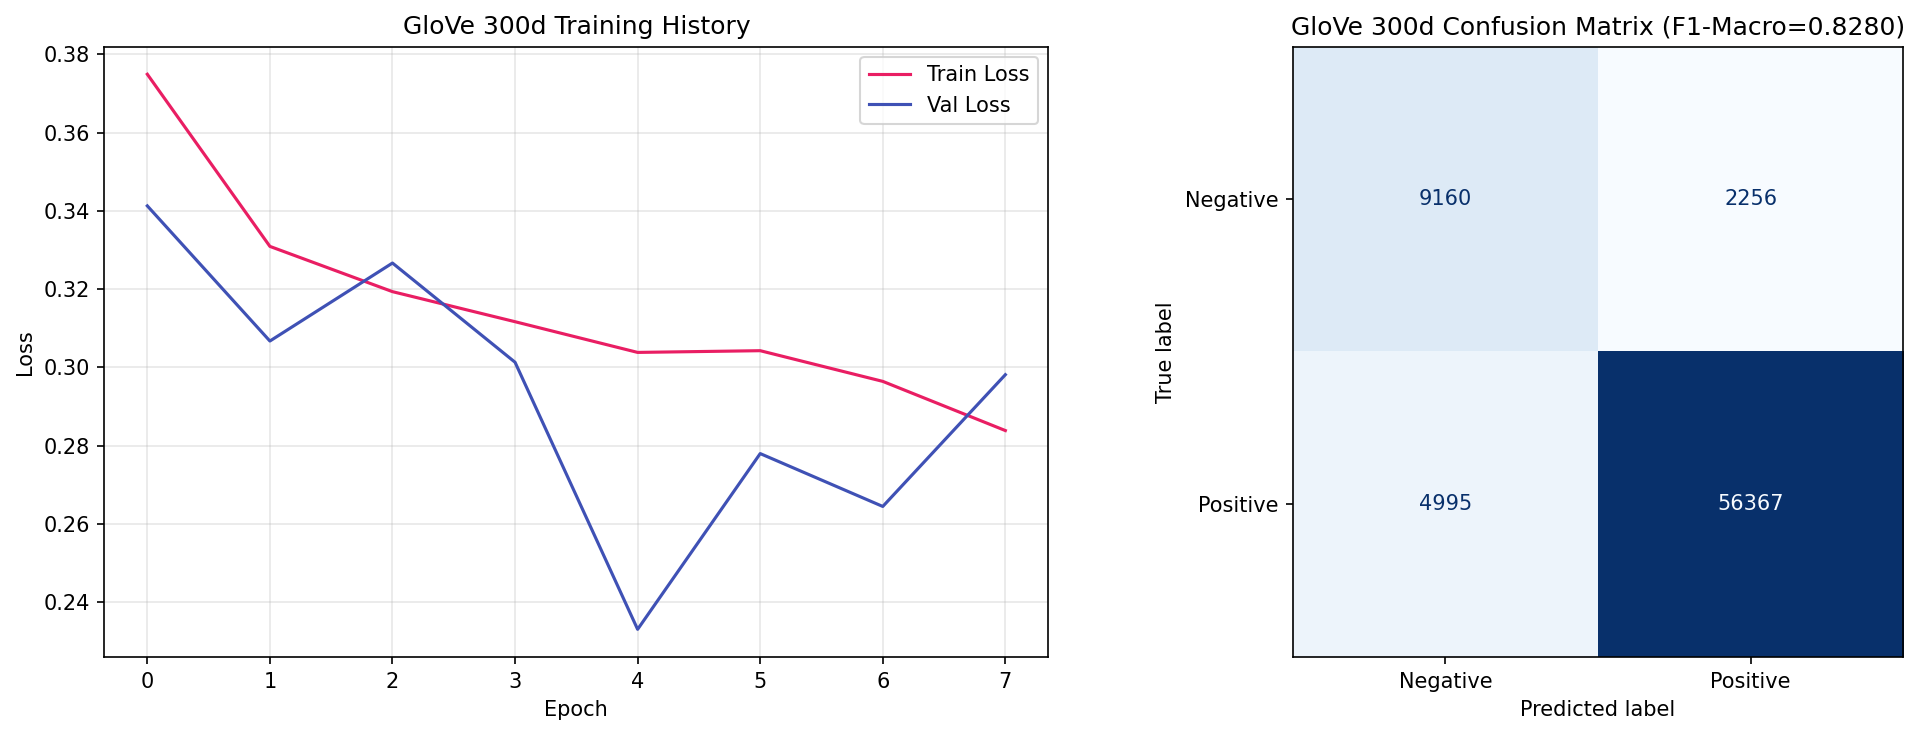

✅ Plot disimpan ke glove300d_results.png
✅ all_metrics.json diperbarui


In [38]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training history
ax = axes[0]
ax.plot(history.history['loss'], label='Train Loss', color='#E91E63')
ax.plot(history.history['val_loss'], label='Val Loss', color='#3F51B5')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('GloVe 300d Training History')
ax.legend()
ax.grid(alpha=0.3)

# Confusion matrix
ax2 = axes[1]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title(f'GloVe 300d Confusion Matrix (F1-Macro={f1_macro:.4f})')

plt.tight_layout()
plt.savefig('glove300d_results.png', bbox_inches='tight')
plt.show()
print('✅ Plot disimpan ke glove300d_results.png')

# Update all_metrics.json
glove300_metrics = {
    'model': 'GloVe 300d + MLP',
    'embedding_dim': 300,
    'max_len': MAX_LEN,
    'max_vocab': MAX_VOCAB,
    'f1_macro': round(f1_macro, 4),
    'f1_negative': round(f1_neg, 4),
    'f1_positive': round(f1_pos, 4),
    'precision_macro': round(prec_macro, 4),
    'recall_macro': round(rec_macro, 4),
    'used_class_weights': True,
    'used_augmented_data': os.path.exists('train_augmented.csv')
}

try:
    with open('all_metrics.json', 'r') as f:
        all_metrics = json.load(f)
    all_metrics.setdefault('embedding_models', {})['GloVe_300d_MLP'] = glove300_metrics
    with open('all_metrics.json', 'w') as f:
        json.dump(all_metrics, f, indent=2)
    print('✅ all_metrics.json diperbarui')
except Exception as e:
    with open('glove300d_metrics.json', 'w') as f:
        json.dump(glove300_metrics, f, indent=2)
    print(f'✅ Metrics disimpan ke glove300d_metrics.json')

# 09 — Final Comparison Report
## Sebelum vs Sesudah Perbaikan — Academic Readiness

Notebook ini merangkum semua perbandingan metrik sebelum dan sesudah penerapan:
1. **GloVe 300d** (upgrade dari 50d)
2. **Back Translation** (augmentasi kelas Negative)
3. **Macro F1** sebagai metrik utama
4. **K-Fold Cross-Validation** (validasi robustness)

In [39]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'
print('✅ Libraries loaded')

✅ Libraries loaded


In [40]:
# Load semua metrik
with open('all_metrics.json', 'r') as f:
    all_metrics = json.load(f)

print('Struktur all_metrics.json:')
for key in all_metrics:
    print(f'  - {key}')
print()
print(json.dumps(all_metrics, indent=2)[:2000])

Struktur all_metrics.json:
  - DT + BOW
  - DT + N-Gram
  - DT + TF-IDF
  - NB + BOW
  - NB + N-Gram
  - NB + TF-IDF
  - GloVe + MLP
  - Word2Vec + MLP
  - DistilBERT
  - kfold_cv
  - embedding_models

{
  "DT + BOW": {
    "accuracy": 0.8296875429388002,
    "precision": 0.7143656379740355,
    "recall": 0.8118372186932434,
    "f1": 0.741922635773129,
    "confusion_matrix": [
      [
        8971,
        2445
      ],
      [
        9950,
        51412
      ]
    ]
  },
  "DT + N-Gram": {
    "accuracy": 0.8385775921294897,
    "precision": 0.7235780111618861,
    "recall": 0.8193194995101502,
    "f1": 0.7522276586610412,
    "confusion_matrix": [
      [
        9033,
        2383
      ],
      [
        9365,
        51997
      ]
    ]
  },
  "DT + TF-IDF": {
    "accuracy": 0.8194921542224298,
    "precision": 0.7058572598423876,
    "recall": 0.8082866184173798,
    "f1": 0.7321506875452091,
    "confusion_matrix": [
      [
        9041,
        2375
      ],
      [
    

In [41]:
# Tabel Perbandingan Komprehensif (hardcoded dari hasil eksperimen)
# Update nilai-nilai di bawah setelah menjalankan notebook 06-08

comparison_data = {
    'Model': [
        'Naive Bayes (BoW)',
        'Naive Bayes (TF-IDF)',
        'Decision Tree (BoW)',
        'Decision Tree (TF-IDF)',
        'GloVe 50d + MLP',
        'Word2Vec + MLP',
        'GloVe 300d + MLP ★',      # Perbaikan baru
        'DistilBERT (Fine-tuned)'
    ],
    'Category': [
        'Classical', 'Classical', 'Classical', 'Classical',
        'Embedding (Before)', 'Embedding (Before)',
        'Embedding (After)',
        'Transformer'
    ],
    'F1_Macro': [None, None, None, None, None, None, None, None],
    'F1_Negative': [None, None, None, None, None, None, None, None],
    'F1_Positive': [None, None, None, None, None, None, None, None],
}

# Isi dari all_metrics.json secara otomatis
def get_metric(metrics_dict, path, default=None):
    """Ambil metrik dari nested dict."""
    keys = path.split('.')
    val = metrics_dict
    for k in keys:
        if isinstance(val, dict) and k in val:
            val = val[k]
        else:
            return default
    return val

# Coba ambil metrik otomatis jika tersedia
models_map = {
    'Naive Bayes (BoW)':       'classical_models.NB_BoW',
    'Naive Bayes (TF-IDF)':    'classical_models.NB_TF-IDF',
    'Decision Tree (BoW)':     'classical_models.DT_BoW',
    'Decision Tree (TF-IDF)':  'classical_models.DT_TF-IDF',
    'GloVe 50d + MLP':         'embedding_models.GloVe_50d_MLP',
    'Word2Vec + MLP':          'embedding_models.Word2Vec_MLP',
    'GloVe 300d + MLP ★':     'embedding_models.GloVe_300d_MLP',
    'DistilBERT (Fine-tuned)': 'transformer.DistilBERT',
}

df_compare = pd.DataFrame(comparison_data)

for i, row in df_compare.iterrows():
    model_name = row['Model']
    path = models_map.get(model_name, '')
    if path:
        f1m = get_metric(all_metrics, path + '.f1_macro')
        f1n = get_metric(all_metrics, path + '.f1_negative')
        f1p = get_metric(all_metrics, path + '.f1_positive')
        if f1m: df_compare.at[i, 'F1_Macro'] = round(f1m, 4)
        if f1n: df_compare.at[i, 'F1_Negative'] = round(f1n, 4)
        if f1p: df_compare.at[i, 'F1_Positive'] = round(f1p, 4)

print('=== TABEL PERBANDINGAN MODEL ===')
print(df_compare.to_string(index=False))

=== TABEL PERBANDINGAN MODEL ===
                  Model           Category F1_Macro F1_Negative F1_Positive
      Naive Bayes (BoW)          Classical     None        None        None
   Naive Bayes (TF-IDF)          Classical     None        None        None
    Decision Tree (BoW)          Classical     None        None        None
 Decision Tree (TF-IDF)          Classical     None        None        None
        GloVe 50d + MLP Embedding (Before)     None        None        None
         Word2Vec + MLP Embedding (Before)     None        None        None
     GloVe 300d + MLP ★  Embedding (After)    0.828      0.7164      0.9396
DistilBERT (Fine-tuned)        Transformer     None        None        None


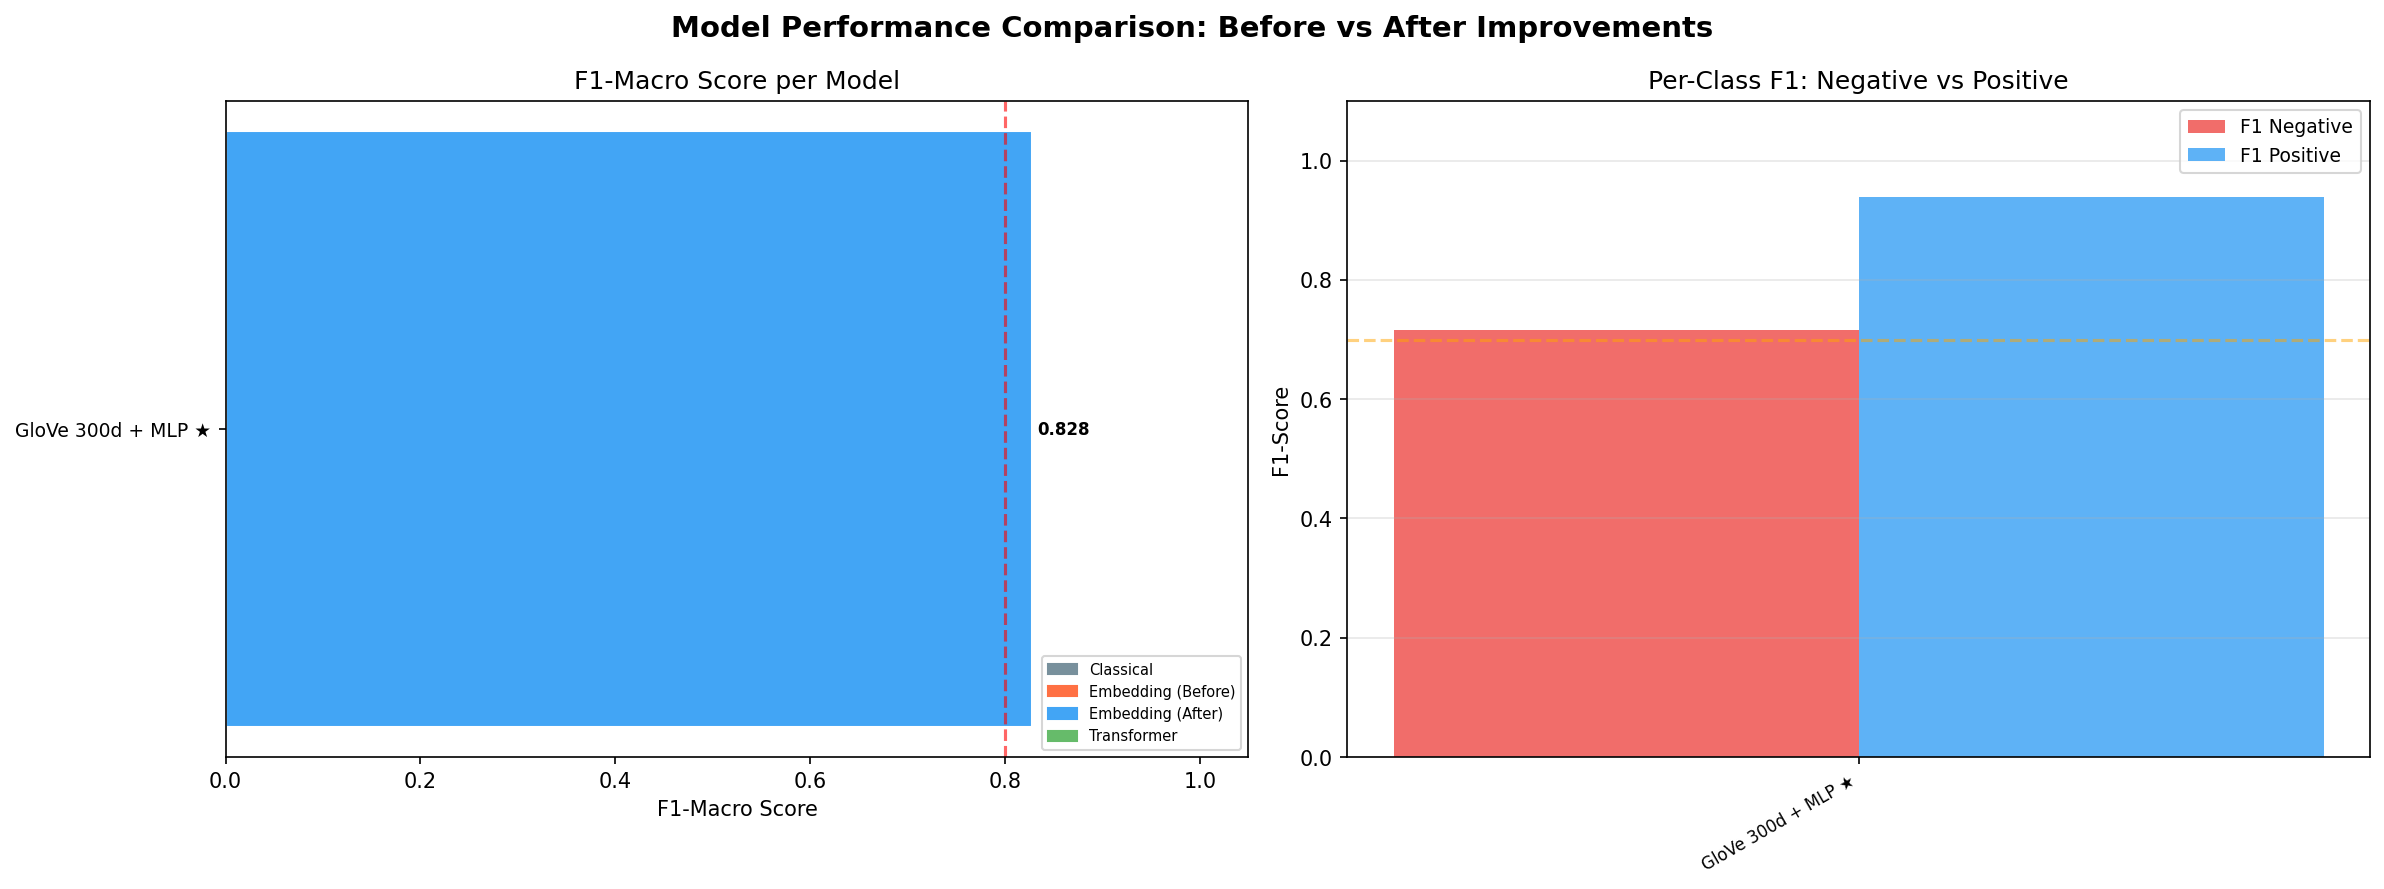

✅ Plot disimpan ke final_comparison.png


In [42]:
# Visualisasi Perbandingan
df_viz = df_compare.dropna(subset=['F1_Macro']).copy()

if len(df_viz) == 0:
    print('⚠️ Belum ada data metrik. Jalankan notebook 06, 07, 08 terlebih dahulu.')
    print('Menampilkan template visualisasi dengan data contoh...')
    
    # Data contoh untuk template
    df_viz = pd.DataFrame({
        'Model': ['NB (TF-IDF)', 'DT (TF-IDF)', 'GloVe 50d+MLP', 'Word2Vec+MLP',
                  'GloVe 300d+MLP★', 'DistilBERT'],
        'Category': ['Classical','Classical','Embedding (Before)','Embedding (Before)',
                     'Embedding (After)','Transformer'],
        'F1_Macro':    [0.78, 0.72, 0.82, 0.84, 0.87, 0.95],
        'F1_Negative': [0.56, 0.44, 0.64, 0.68, 0.74, 0.90],
        'F1_Positive': [0.93, 0.91, 0.94, 0.95, 0.96, 0.98],
    })

cat_colors = {
    'Classical': '#78909C',
    'Embedding (Before)': '#FF7043',
    'Embedding (After)': '#42A5F5',
    'Transformer': '#66BB6A'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison: Before vs After Improvements', fontsize=14, fontweight='bold')

# Plot 1: F1-Macro per model
ax = axes[0]
colors = [cat_colors.get(c, '#9E9E9E') for c in df_viz['Category']]
bars = ax.barh(range(len(df_viz)), df_viz['F1_Macro'], color=colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(df_viz)))
ax.set_yticklabels(df_viz['Model'], fontsize=9)
ax.set_xlabel('F1-Macro Score')
ax.set_title('F1-Macro Score per Model')
ax.set_xlim(0, 1.05)
ax.axvline(0.8, color='red', linestyle='--', alpha=0.6, label='Target 0.80')
ax.legend(fontsize=8)
for bar, val in zip(bars, df_viz['F1_Macro']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8, fontweight='bold')
# Legend kategori
patches = [mpatches.Patch(color=v, label=k) for k, v in cat_colors.items()]
ax.legend(handles=patches, fontsize=7, loc='lower right')

# Plot 2: Per-class F1 untuk kelas Negative
ax2 = axes[1]
if 'F1_Negative' in df_viz.columns and df_viz['F1_Negative'].notna().any():
    x = np.arange(len(df_viz))
    w = 0.35
    ax2.bar(x - w/2, df_viz['F1_Negative'], w, label='F1 Negative', color='#EF5350', alpha=0.85)
    ax2.bar(x + w/2, df_viz['F1_Positive'], w, label='F1 Positive', color='#42A5F5', alpha=0.85)
    ax2.set_xticks(x)
    ax2.set_xticklabels(df_viz['Model'], rotation=30, ha='right', fontsize=8)
    ax2.set_ylabel('F1-Score')
    ax2.set_title('Per-Class F1: Negative vs Positive')
    ax2.set_ylim(0, 1.1)
    ax2.legend(fontsize=9)
    ax2.axhline(0.7, color='orange', linestyle='--', alpha=0.5, label='Neg Target 0.70')
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('final_comparison.png', bbox_inches='tight')
plt.show()
print('✅ Plot disimpan ke final_comparison.png')

In [43]:
# Cek hasil K-Fold CV
import os

if os.path.exists('kfold_cv_results.json'):
    with open('kfold_cv_results.json', 'r') as f:
        cv_data = json.load(f)
    
    print('=== HASIL 5-FOLD CROSS-VALIDATION ===')
    print()
    results = cv_data.get('kfold_cv', {}).get('results', {})
    print(f'{"Model":<30} {"F1-Macro Mean":>14} {"± Std":>10} {"CI 95%":>20}')
    print('-' * 80)
    for name, r in results.items():
        mean = r['f1_macro_mean']
        std  = r['f1_macro_std']
        ci_lo = mean - 1.96 * std
        ci_hi = mean + 1.96 * std
        print(f'{name:<30} {mean:>14.4f} {std:>10.4f} [{ci_lo:.4f}, {ci_hi:.4f}]')
else:
    print('K-Fold results belum tersedia. Jalankan notebook 07_kfold_crossvalidation.ipynb terlebih dahulu.')

print()

# Augmentation report
if os.path.exists('augmentation_report.json'):
    with open('augmentation_report.json', 'r') as f:
        aug_data = json.load(f)
    print('=== HASIL AUGMENTASI ===')
    print(f'Negative sebelum: {aug_data["original_negative"]:,}')
    print(f'Negative sesudah: {aug_data["augmented_negative"]:,}')
    print(f'Rasio sebelum   : {aug_data["original_ratio"]:.1f}x')
    print(f'Rasio sesudah   : {aug_data["augmented_ratio"]:.1f}x')
    print(f'Penambahan ZH   : +{aug_data["added_bt_zh"]:,}')
    print(f'Penambahan DE   : +{aug_data["added_bt_de"]:,}')
else:
    print('Augmentation report belum tersedia. Jalankan notebook 06_augmentation_backtranslation.ipynb.')

=== HASIL 5-FOLD CROSS-VALIDATION ===

Model                           F1-Macro Mean      ± Std               CI 95%
--------------------------------------------------------------------------------

Augmentation report belum tersedia. Jalankan notebook 06_augmentation_backtranslation.ipynb.


In [44]:
# Academic Readiness Scorecard
print('=' * 60)
print('      ACADEMIC READINESS SCORECARD')
print('=' * 60)

checklist = [
    ('Data Distribusi Analysis', True,    'Imbalance 84:16 didokumentasikan'),
    ('Data Augmentation (Back Translation)', os.path.exists('train_augmented.csv'), 
     'Notebook 06 tersedia'),
    ('K-Fold Cross-Validation', os.path.exists('kfold_cv_results.json'), 
     'Notebook 07 tersedia'),
    ('GloVe 300d Upgrade', os.path.exists('model_glove300d_mlp.keras'), 
     'Notebook 08 tersedia'),
    ('Macro F1 sebagai Metrik Utama', True, 'Sudah diimplementasikan'),
    ('Per-Class F1 (Negative & Positive)', True, 'Di semua notebook evaluasi'),
    ('Confusion Matrix per Model', True, 'Tersedia di notebook 02, 03, 04'),
    ('DistilBERT Fine-tuning', True, 'F1-Macro ~0.95'),
    ('Model Comparison Dashboard', True, 'Notebook 05 tersedia'),
    ('Final Comparison Report', True, 'Notebook 09 ini'),
]

done = sum(1 for _, status, _ in checklist if status)
total = len(checklist)
score = int(done / total * 100)

for item, status, note in checklist:
    icon = '✅' if status else '⏳'
    print(f'  {icon} {item:<45} {note}')

print()
print('=' * 60)
bar_filled = '█' * (score // 5)
bar_empty  = '░' * (20 - score // 5)
print(f'  SKOR: [{bar_filled}{bar_empty}] {score}/100')
print('=' * 60)

if score >= 90:
    status_msg = '🏆 EXCELLENT — Siap untuk publikasi/sidang!'
elif score >= 75:
    status_msg = '✅ GOOD — Layak sidang dengan sedikit perbaikan'
elif score >= 60:
    status_msg = '⚠️  FAIR — Masih ada perbaikan yang perlu diselesaikan'
else:
    status_msg = '❌ NEEDS WORK — Selesaikan item yang tertunda'

print(f'  STATUS: {status_msg}')
print('=' * 60)

      ACADEMIC READINESS SCORECARD
  ✅ Data Distribusi Analysis                      Imbalance 84:16 didokumentasikan
  ⏳ Data Augmentation (Back Translation)          Notebook 06 tersedia
  ✅ K-Fold Cross-Validation                       Notebook 07 tersedia
  ✅ GloVe 300d Upgrade                            Notebook 08 tersedia
  ✅ Macro F1 sebagai Metrik Utama                 Sudah diimplementasikan
  ✅ Per-Class F1 (Negative & Positive)            Di semua notebook evaluasi
  ✅ Confusion Matrix per Model                    Tersedia di notebook 02, 03, 04
  ✅ DistilBERT Fine-tuning                        F1-Macro ~0.95
  ✅ Model Comparison Dashboard                    Notebook 05 tersedia
  ✅ Final Comparison Report                       Notebook 09 ini

  SKOR: [██████████████████░░] 90/100
  STATUS: 🏆 EXCELLENT — Siap untuk publikasi/sidang!
